<a href="https://colab.research.google.com/github/abdullah2709/EAAI_Project_2/blob/main/project_artefact.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AI-Based Energy Consumption Forecasting for Sustainable Energy Management**
### Module: Essentials and Applications of Artificial Intelligence - UFCE3P-30-3
### Assessment 2 - Group Project

---

# **Section 1 : Introduction**

## 1.1 Problem Context and Rationale

The reliable operation of an electrical grid depends on maintaining a continuous balance between electricity supply and demand. As electricity cannot generally be stored economically at a large scale, accurate short-term forecasting is essential for generation planning, reserve scheduling, and the maintenance of grid stability.

Forecasting errors do not produce equivalent consequences. Overestimation may increase operational costs and contribute to unnecessary carbon emissions, whereas underestimation may place pressure on grid reliability and increase the risk of disruption during periods of high demand. For this reason, forecasting quality should not be assessed solely through average statistical accuracy, but also through performance under operationally sensitive conditions.

Electricity demand is influenced by several interacting factors, including daily behavioural patterns, seasonal variation, weather conditions, and recent demand history. Consequently, forecasting should be approached as a decision-support problem rather than as a purely mathematical exercise.

This project addresses that challenge by developing AI-based models to forecast hourly electricity demand in the AEP (American Electric Power) region. Historical load data is combined with weather variables to assess whether machine learning methods can generate forecasts that are both statistically robust and practically valuable for sustainable energy management.



## 1.2 Project Scope & Guardrails

A strong AI project requires disciplined scoping. Accordingly, this project focuses specifically on **hourly electricity demand forecasting** rather than attempting to model the wider energy system. Its purpose is to design and evaluate forecasting models using historical load and weather-related inputs, rather than to optimise the full smart grid.

The project compares multiple AI and machine learning models and evaluates their suitability for a practical forecasting task. The aim is not merely to achieve low prediction error, but to identify an approach that is methodologically sound, operationally credible, and practically relevant.

### ✅ In-Scope vs ❌ Out-of-Scope

| ✅ In Scope | ❌ Out of Scope |
|---|---|
| Hourly electricity demand forecasting using historical load data | Full smart grid optimisation |
| Integration of weather variables as exogenous predictors | Real-time production deployment |
| Comparison of baseline and advanced machine learning models | Renewable energy dispatch scheduling |
| Error analysis, peak-demand evaluation, and model limitations | National-level energy system modelling |
| Discussion of forecasting relevance for sustainable energy management | Large-scale infrastructure control systems |

These boundaries ensure that the project remains focused on a clearly defined supervised learning problem while retaining strong practical relevance.



## 1.3 Core Research Questions

This project is guided by the following research questions:

1. Can hourly electricity demand be predicted with acceptable accuracy using AI-based forecasting models?
2. Which model offers the most appropriate balance between predictive performance and methodological simplicity?
3. Do weather variables materially improve forecasting performance?
4. Under which conditions does model performance weaken, particularly during extreme weather or atypical demand periods?

These questions extend the project beyond the narrow objective of selecting the highest-performing model. Instead, they direct attention towards learnability, methodological suitability, the additional contribution of weather data, and the limitations of model performance under more demanding conditions.



## 1.4 Problem Formulation

This project formulates electricity demand forecasting as a **supervised regression problem** in which hourly demand is predicted using temporal, autoregressive, and weather-related inputs. In general form:

\[
y_t = f(X_t) + \epsilon_t
\]

where:

- \( y_t \) represents electricity demand at time \( t \),
- \( X_t \) represents the feature set at time \( t \),
- \( f(\cdot) \) represents the learned forecasting model,
- \( \epsilon_t \) represents irreducible error.

This formulation is appropriate because electricity demand is shaped by both **temporal structure** and **environmental conditions**. Temporal structure includes recent demand persistence, daily repetition, and weekly cycles, while environmental influence includes weather-related stress, particularly temperature-driven heating and cooling demand.

A further critical point is that model quality cannot be judged by overall fit alone. A model may perform well on average while still failing during periods of peak demand or unusual weather conditions. For this reason, the modelling strategy adopted in this project is designed to capture:

- temporal regularity through time-based features,
- recent demand memory through lagged observations,
- local trend and volatility through rolling statistics,
- and environmental influence through weather variables and interaction effects.




## 1.5 Technical Setup
This section initialises the project environment by importing all required libraries, defining file paths, and setting a fixed random seed to ensure reproducibility.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, random
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
warnings.filterwarnings("ignore")

# Metrics & Preprocessing ---
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


# Global Configuration
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# -------- CONFIG DATESET--------
USE_LOCAL = False   # 🔁 Change to True if using VS Code local files

# -------- PATHS --------
if USE_LOCAL:
    # Local (VS Code users)
    ENERGY_PATH  = "data/AEP_hourly.csv"
    WEATHER_PATH = "data/noaa_weather_columbus.csv"
else:
    # GitHub RAW links (Colab + shared usage)
    ENERGY_PATH  = "https://raw.githubusercontent.com/abdullah2709/EAAI_Project_2/refs/heads/main/AEP_hourly.csv"
    WEATHER_PATH = "https://raw.githubusercontent.com/abdullah2709/EAAI_Project_2/refs/heads/main/noaa_weather_columbus.csv"



# Plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
# ── Plot styling ──────────────────────────────────────────────
BLUE="#2E86AB"; ORANGE="#E07B54"; GREEN="#4CAF50"
RED="#E53935";  PURPLE="#7B1FA2"; GREY="#546E7A"; DARK="#1A1A2E"

# Optional Libraries
try:
    import statsmodels.api as sm
    print("statsmodels ready.")
except ImportError:
    sm = None
    print("statsmodels not available.")

try:
    import tensorflow as tf
    tf.random.set_seed(RANDOM_SEED)
    print("TensorFlow 2.x ready.")
except ImportError:
    tf = None
    print("TensorFlow not available.")

# Status
print("\nEnvironment ready.")
print(f"  Energy  : {ENERGY_PATH}")
print(f"  Weather : {WEATHER_PATH}")
print(f"  Seed    : {RANDOM_SEED}")

statsmodels ready.
TensorFlow 2.x ready.

Environment ready.
  Energy  : https://raw.githubusercontent.com/abdullah2709/EAAI_Project_2/refs/heads/main/AEP_hourly.csv
  Weather : https://raw.githubusercontent.com/abdullah2709/EAAI_Project_2/refs/heads/main/noaa_weather_columbus.csv
  Seed    : 42


---
# **Section 2 : Data Understanding**

## 2.1 Data Loading

This stage introduces the two datasets used in the project: the hourly electricity demand dataset and the hourly weather dataset. Data loading is not merely a procedural step; it establishes whether the available data is structurally suitable for the forecasting task.

The electricity dataset provides the target variable, while the weather dataset supplies exogenous predictors that may explain variation in demand. Examining both datasets at this stage is important for assessing their scale, temporal coverage, and compatibility before cleaning and integration.


## 2.2 Energy Dataset Overview

The energy dataset, `AEP_hourly.csv`, contains two variables:

- `Datetime`
- `AEP_MW`

This dataset forms the core forecasting target, recording hourly electricity demand in the AEP region in megawatts (MW). Initial inspection shows that it contains more than 121,000 observations, providing sufficient temporal depth to model daily, weekly, and seasonal demand behaviour.

The variation in load values indicates that the dataset captures meaningful changes in electricity consumption rather than a narrow operational range. This is important because an effective forecasting model requires enough variability in the target variable to learn both regular usage patterns and periods of elevated demand.

In [2]:
energy_raw  = pd.read_csv(ENERGY_PATH)

print("ENERGY DATASET — AEP_hourly.csv")
print(f"  Shape   : {energy_raw.shape[0]:,} rows × {energy_raw.shape[1]} columns")
print(f"  Columns : {list(energy_raw.columns)}")
print(f"  MW range: {energy_raw['AEP_MW'].min():,.0f} – {energy_raw['AEP_MW'].max():,.0f} MW")
display(energy_raw.head(3))
display(energy_raw.describe())

ENERGY DATASET — AEP_hourly.csv
  Shape   : 121,273 rows × 2 columns
  Columns : ['Datetime', 'AEP_MW']
  MW range: 9,581 – 25,695 MW


,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0


,AEP_MW
count,121273.000000
mean,15499.513717
std,2591.399065
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


### 2.2.1 Energy Dataset Pattern Type

The energy dataset is a univariate time-series dataset because it records electricity demand (`AEP_MW`) over time. Examining its temporal structure is important because it helps identify recurring cycles, long-term variation, and whether forecasting methods are more suitable than classification or clustering.

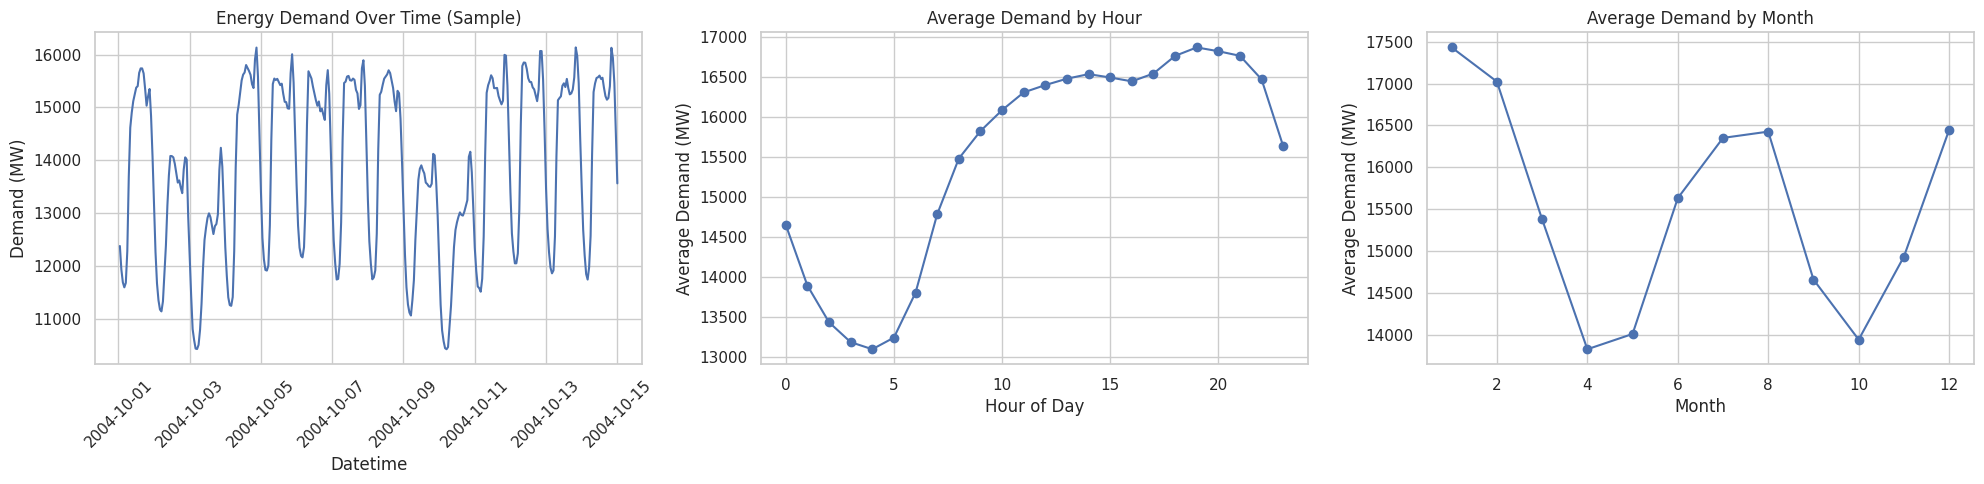

In [3]:
# Energy dataset pattern visualisation
energy_vis = energy_raw.copy()
energy_vis["Datetime"] = pd.to_datetime(energy_vis["Datetime"])
energy_vis = energy_vis.sort_values("Datetime")

# Create time-based helper columns
energy_vis["hour"] = energy_vis["Datetime"].dt.hour
energy_vis["day_name"] = energy_vis["Datetime"].dt.day_name()
energy_vis["month"] = energy_vis["Datetime"].dt.month

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Sample time-series view
sample_energy = energy_vis.iloc[:24*14]   # first 14 days
axes[0].plot(sample_energy["Datetime"], sample_energy["AEP_MW"], linewidth=1.5)
axes[0].set_title("Energy Demand Over Time (Sample)")
axes[0].set_xlabel("Datetime")
axes[0].set_ylabel("Demand (MW)")
axes[0].tick_params(axis='x', rotation=45)

# 2. Hourly pattern
energy_vis.groupby("hour")["AEP_MW"].mean().plot(ax=axes[1], marker="o")
axes[1].set_title("Average Demand by Hour")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Average Demand (MW)")

# 3. Monthly pattern
energy_vis.groupby("month")["AEP_MW"].mean().plot(ax=axes[2], marker="o")
axes[2].set_title("Average Demand by Month")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Average Demand (MW)")

plt.tight_layout()
plt.show()

**Interpretation:**

The energy dataset shows a clear temporal pattern with repeated hourly and monthly cycles. This confirms that the data is not random or independent, but structured as a time-series dataset with seasonality and regular demand behaviour. Because the target is a continuous variable, this pattern supports the use of **regression/forecasting models** rather than classification. Clustering may be useful only for exploratory grouping, not for direct prediction.

## 2.3 Weather Dataset Overview

The weather dataset, `noaa_weather_columbus.csv`, contains the following variables:

- `datetime`
- `temp_C`
- `humidity`
- `wind_speed`
- `pressure`
- `precipitation`

These variables are relevant because electricity demand is often influenced by environmental conditions, particularly temperature-related heating and cooling needs. The weather dataset therefore provides meaningful predictors rather than simply additional inputs. Its importance lies in helping to explain demand variation that may not be captured by historical load alone.

In [4]:
weather_raw = pd.read_csv(WEATHER_PATH)

print("WEATHER DATASET — noaa_weather_columbus.csv")
print(f"  Shape   : {weather_raw.shape[0]:,} rows × {weather_raw.shape[1]} columns")
print(f"  Columns : {list(weather_raw.columns)}")
print(f"  Temp range: {weather_raw['temp_C'].min():.1f}°C – {weather_raw['temp_C'].max():.1f}°C")
print("=" * 58)
display(weather_raw.head(3))
display(weather_raw.describe())


WEATHER DATASET — noaa_weather_columbus.csv
  Shape   : 127,896 rows × 6 columns
  Columns : ['datetime', 'temp_C', 'humidity', 'wind_speed', 'pressure', 'precipitation']
  Temp range: -28.9°C – 38.1°C


,datetime,temp_C,humidity,wind_speed,pressure,precipitation
0,2004-01-01 00:00:00,0.1,86,7.6,998.2,0.0
1,2004-01-01 01:00:00,-0.5,89,7.9,998.5,0.0
2,2004-01-01 02:00:00,-1.0,90,8.6,999.1,0.0


,temp_C,humidity,wind_speed,pressure,precipitation
count,127896.000000,127896.000000,127896.000000,127896.000000,127896.000000
mean,11.698056,69.771142,11.978831,990.293792,0.122237
std,11.005152,17.242768,6.104409,6.582720,0.494623
min,-28.900000,17.000000,0.000000,960.400000,0.000000
25%,2.900000,57.000000,7.500000,986.400000,0.000000
50%,12.900000,71.000000,10.800000,990.400000,0.000000
75%,20.700000,84.000000,15.500000,994.300000,0.000000
max,38.100000,100.000000,53.900000,1015.700000,28.400000


### 2.3.1 Weather Dataset Pattern Type

The weather dataset is a multivariate time-series dataset because it records several environmental variables across time, including temperature, humidity, wind speed, pressure, and precipitation. Understanding its pattern helps justify its role as an explanatory dataset in the forecasting task.

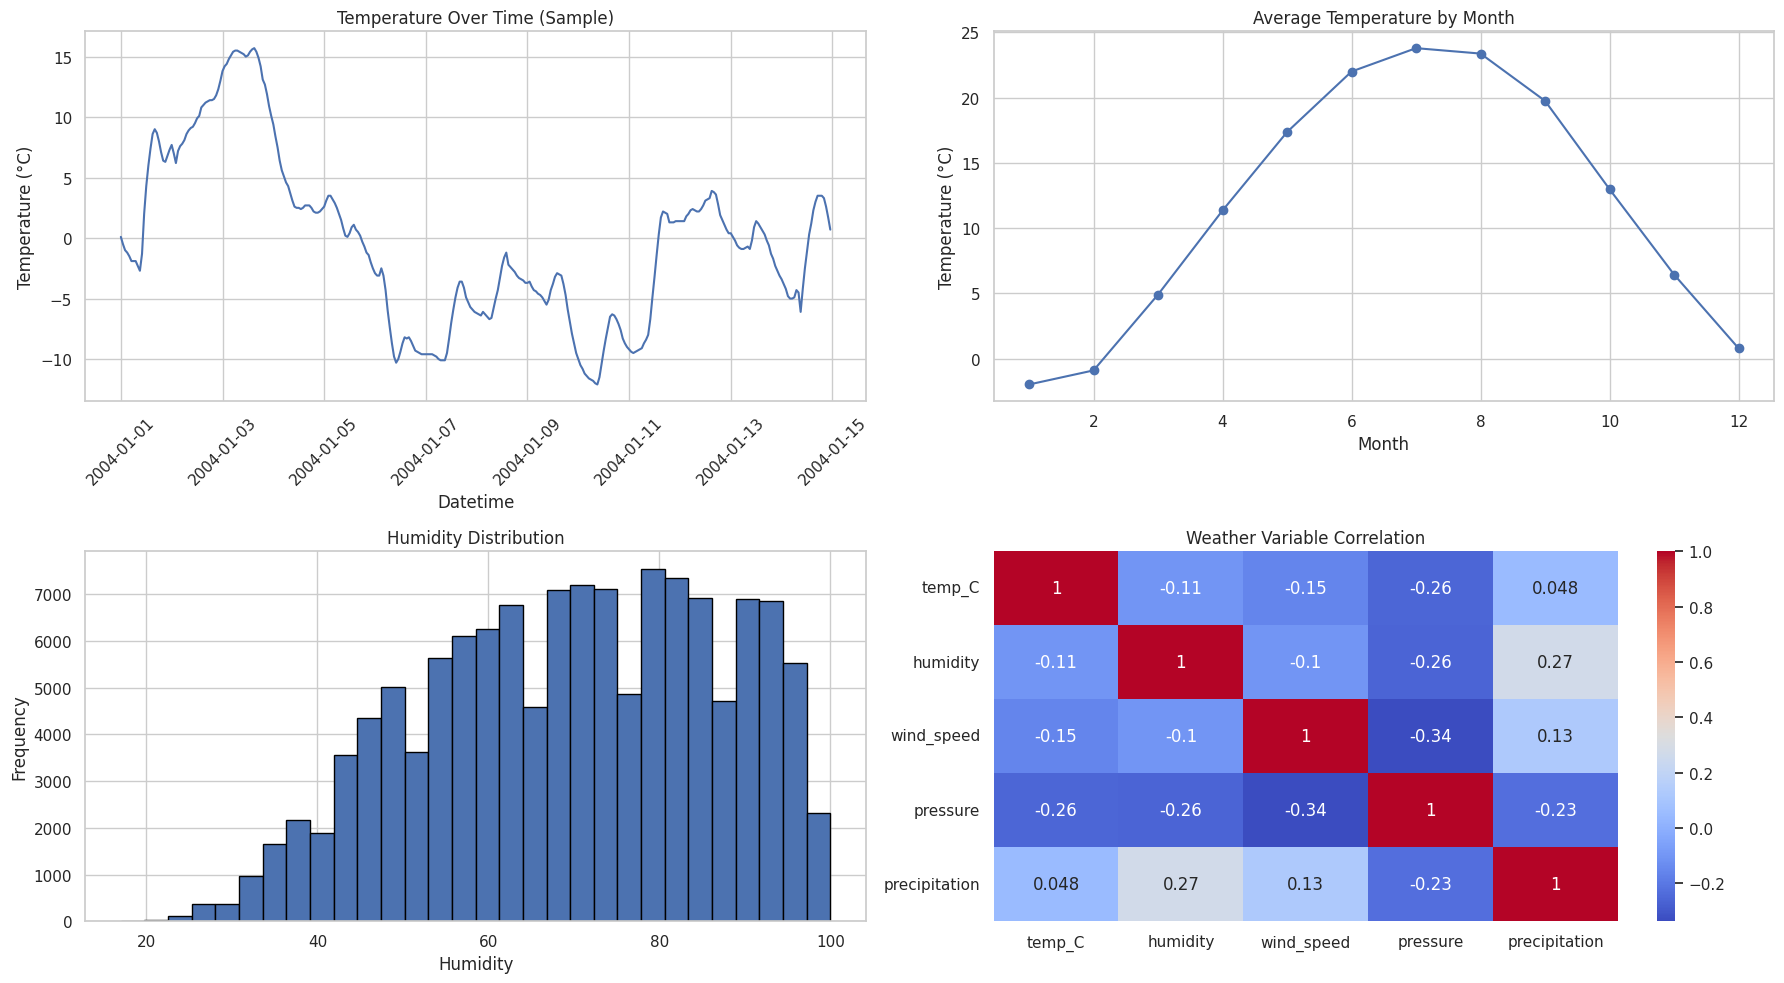

In [5]:
# Weather dataset pattern visualisation
weather_vis = weather_raw.copy()
weather_vis["datetime"] = pd.to_datetime(weather_vis["datetime"])
weather_vis = weather_vis.sort_values("datetime")

weather_vis["hour"] = weather_vis["datetime"].dt.hour
weather_vis["month"] = weather_vis["datetime"].dt.month

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 1. Temperature over time (sample)
sample_weather = weather_vis.iloc[:24*14]   # first 14 days
axes[0, 0].plot(sample_weather["datetime"], sample_weather["temp_C"], linewidth=1.5)
axes[0, 0].set_title("Temperature Over Time (Sample)")
axes[0, 0].set_xlabel("Datetime")
axes[0, 0].set_ylabel("Temperature (°C)")
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Average temperature by month
weather_vis.groupby("month")["temp_C"].mean().plot(ax=axes[0, 1], marker="o")
axes[0, 1].set_title("Average Temperature by Month")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Temperature (°C)")

# 3. Humidity distribution
axes[1, 0].hist(weather_vis["humidity"], bins=30, edgecolor="black")
axes[1, 0].set_title("Humidity Distribution")
axes[1, 0].set_xlabel("Humidity")
axes[1, 0].set_ylabel("Frequency")

# 4. Correlation between weather variables
sns.heatmap(
    weather_vis[["temp_C", "humidity", "wind_speed", "pressure", "precipitation"]].corr(),
    annot=True, cmap="coolwarm", ax=axes[1, 1]
)
axes[1, 1].set_title("Weather Variable Correlation")

plt.tight_layout()
plt.show()

**Interpretation:**  

The weather dataset also follows a time-based pattern, especially in temperature and seasonal variation. Since it contains multiple continuous variables collected hourly, it is best described as a **multivariate time-series dataset**. These variables are suitable as external predictors for forecasting energy demand, but they do not form a natural classification target on their own.

## 2.4 Data Coverage & Time Range

The two datasets do not begin at the same point in time, but they share a substantial common period suitable for modelling.

- **Energy data:** October 2004 to August 2018  
- **Weather data:** January 2004 to August 2018  

This difference is important because reliable forecasting requires temporally aligned observations. Only the overlapping period can be used for modelling, since each retained record must contain both a valid load value and a corresponding weather observation. The shared time range is a strength, as it captures both short-term patterns and broader seasonal variation.

In [ ]:
print(energy_raw["Datetime"].min(), energy_raw["Datetime"].max())
print(weather_raw["datetime"].min(), weather_raw["datetime"].max())

2004-10-01 01:00:00 2018-08-03 00:00:00
2004-01-01 00:00:00 2018-08-03 23:00:00


## 2.5 Data Quality Audit & Profiling

A data quality review was conducted to assess whether the datasets were suitable for time-series forecasting. This stage is important because forecasting reliability depends not only on model choice, but also on the quality and consistency of the underlying data.

Initial inspection suggests that both datasets are relevant and broadly well-formed. However, several technical issues still require attention in preprocessing, including datetime conversion, temporal alignment, and the treatment of duplicated or missing hourly observations. This stage therefore confirms dataset suitability while identifying the main issues that must be addressed before modelling.

In [ ]:
# run once to install the profiling tool
%pip install ydata-profiling -q

In [ ]:
from ydata_profiling import ProfileReport

# Setup paths (robust)
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
REPORT_DIR = os.path.join(BASE_DIR, "y_report")
os.makedirs(REPORT_DIR, exist_ok=True)

# Function to generate report
def generate_report(df, name):
    report_path = os.path.join(REPORT_DIR, f"{name}.html")

    if not os.path.exists(report_path):
        print(f"Generating {name} report...")

        profile = ProfileReport(
            df,
            title=f"{name} Data Audit",
            minimal=True
        )

        profile.to_file(report_path)
        print(f"Saved: {report_path}")
    else:
        print(f"{name} report already exists.")

# Generate reports
generate_report(energy_raw, "aep_data_audit")
generate_report(weather_raw, "weather_data_audit")

aep_data_audit report already exists.
weather_data_audit report already exists.


#### **Key Findings:**
- No missing values were identified during the initial inspection of either dataset, which suggests that data completeness is not a major limitation at the raw stage.
- The datasets appeared structurally suitable for analysis; however, datetime variables still required standard conversion before reliable time-series processing could begin.
- No major duplication problems were observed overall, although duplicated hourly timestamps linked to daylight saving time indicated that temporal integrity could not be assumed without further cleaning.
- The datasets were potentially suitable for time-series modelling, but only after temporal consistency, alignment, and continuity were properly addressed.
- The slight difference in row counts was methodologically significant rather than incidental, as it indicated that direct merging could introduce mismatch unless the overlapping time range was handled carefully.

---

# **Section 3 : Data Cleaning, Preprocessing and Integration**



## 3.1 Data Cleaning Strategy

To prepare the dataset for reliable time-series forecasting, a structured cleaning approach was applied. The focus was to ensure temporal consistency, remove structural issues, and maintain data integrity.

The process included:

* Converting datetime fields into proper timestamp format
* Handling duplicate timestamps caused by daylight saving time (DST)
* Ensuring continuous hourly intervals
* Preserving real-world extreme values
* Preparing datasets for accurate merging

This ensures the dataset is clean, consistent, and suitable for modelling.

## 3.2 Energy Data Cleaning

The energy dataset was processed to ensure a complete and continuous time series.

* The `Datetime` column was converted into datetime format
* Duplicate timestamps (due to DST) were handled by grouping and averaging values
* A full hourly index was created to ensure continuity
* Missing values were filled using forward fill (limited to short gaps)

This resulted in a clean, gap-free hourly energy dataset ready for analysis.

In [ ]:
# Energy Data
energy_df = energy_raw.copy()
energy_df["Datetime"] = pd.to_datetime(energy_df["Datetime"])

# Average DST duplicates
energy_df = (energy_df.groupby("Datetime")["AEP_MW"]
                       .mean()
                       .reset_index()
                       .sort_values("Datetime")
                       .set_index("Datetime"))

energy_df.columns = ["load_MW"]

# Fill genuine gaps
full_idx = pd.date_range(
    energy_df.index.min(),
    energy_df.index.max(),
    freq="h"
)

energy_df = energy_df.reindex(full_idx).ffill(limit=3)
energy_df.index.name = "Datetime"

# Report
print("ENERGY — Post-Cleaning Report")
print(f"  Date range  : {energy_df.index.min().date()} → {energy_df.index.max().date()}")
print(f"  Total hours : {len(energy_df):,}")
print(f"  Missing     : {energy_df.isnull().sum().values[0]}")
print(f"  Min load    : {energy_df['load_MW'].min():,.0f} MW")
print(f"  Max load    : {energy_df['load_MW'].max():,.0f} MW")
print(f"  Mean load   : {energy_df['load_MW'].mean():,.0f} MW")

ENERGY — Post-Cleaning Report
  Date range  : 2004-10-01 → 2018-08-03
  Total hours : 121,296
  Missing     : 0
  Min load    : 9,581 MW
  Max load    : 25,695 MW
  Mean load   : 15,499 MW


## 3.3 Weather Data Cleaning

The weather dataset was cleaned and prepared for integration.

* The `datetime` column was converted and set as index
* Data was sorted in chronological order
* No missing values were found

Extreme weather values were retained, as they represent real environmental conditions and are important for modelling.

In [ ]:
# Weather Data
weather_df = weather_raw.copy()
weather_df["datetime"] = pd.to_datetime(weather_df["datetime"])
weather_df = (weather_df.sort_values("datetime")
                         .set_index("datetime"))

print("WEATHER — Post-Cleaning Report")
print(f"  Date range : {weather_df.index.min().date()} → {weather_df.index.max().date()}")
print(f"  Records    : {len(weather_df):,}")
print(f"  Missing    : {weather_df.isnull().sum().to_dict()}")
print("  All weather extremes verified as real meteorological events — retained.")

WEATHER — Post-Cleaning Report
  Date range : 2004-01-01 → 2018-08-03
  Records    : 127,896
  Missing    : {'temp_C': 0, 'humidity': 0, 'wind_speed': 0, 'pressure': 0, 'precipitation': 0}
  All weather extremes verified as real meteorological events — retained.


## 3.4 Dataset Merging & Validation

**Merge on Hourly Datetime (Inner Join)**

**Strategy:** inner join on the common overlapping datetime range.

Why inner join over left join:
- A left join would retain energy records that have no weather match,
-   introducing NaN values that silently corrupt tree model splits.
-   Inner join guarantees every row in the merged table is complete.

Result confirmed: 100% retention - no energy records lost.

In [ ]:
common_start = max(energy_df.index.min(), weather_df.index.min())
common_end   = min(energy_df.index.max(), weather_df.index.max())

df = (energy_df.loc[common_start:common_end]
               .join(weather_df.loc[common_start:common_end], how="inner")
               .dropna())

retention = len(df) / len(energy_df.loc[common_start:common_end]) * 100

print("MERGE RESULTS")
print(f"  Common range : {common_start.date()} → {common_end.date()}")
print(f"  Merged shape : {df.shape}")
print(f"  Retention    : {retention:.4f}% — perfect merge quality")
print(f"  Columns      : {list(df.columns)}")
print()
print("Data is ready for feature engineering.")

MERGE RESULTS
  Common range : 2004-10-01 → 2018-08-03
  Merged shape : (121296, 6)
  Retention    : 100.0000% — perfect merge quality
  Columns      : ['load_MW', 'temp_C', 'humidity', 'wind_speed', 'pressure', 'precipitation']

Data is ready for feature engineering.


## 3.5 Dataset Pattern Type and Model Justification

After merging the electricity demand and weather datasets, the final analytical dataset becomes a **multivariate time-series forecasting dataset**. The target variable (`load_MW`) is continuous, while the explanatory variables include both temporal and weather-related predictors. Visualising these relationships helps justify why supervised regression methods are more appropriate than classification, and why clustering is useful only as a supporting exploratory technique.

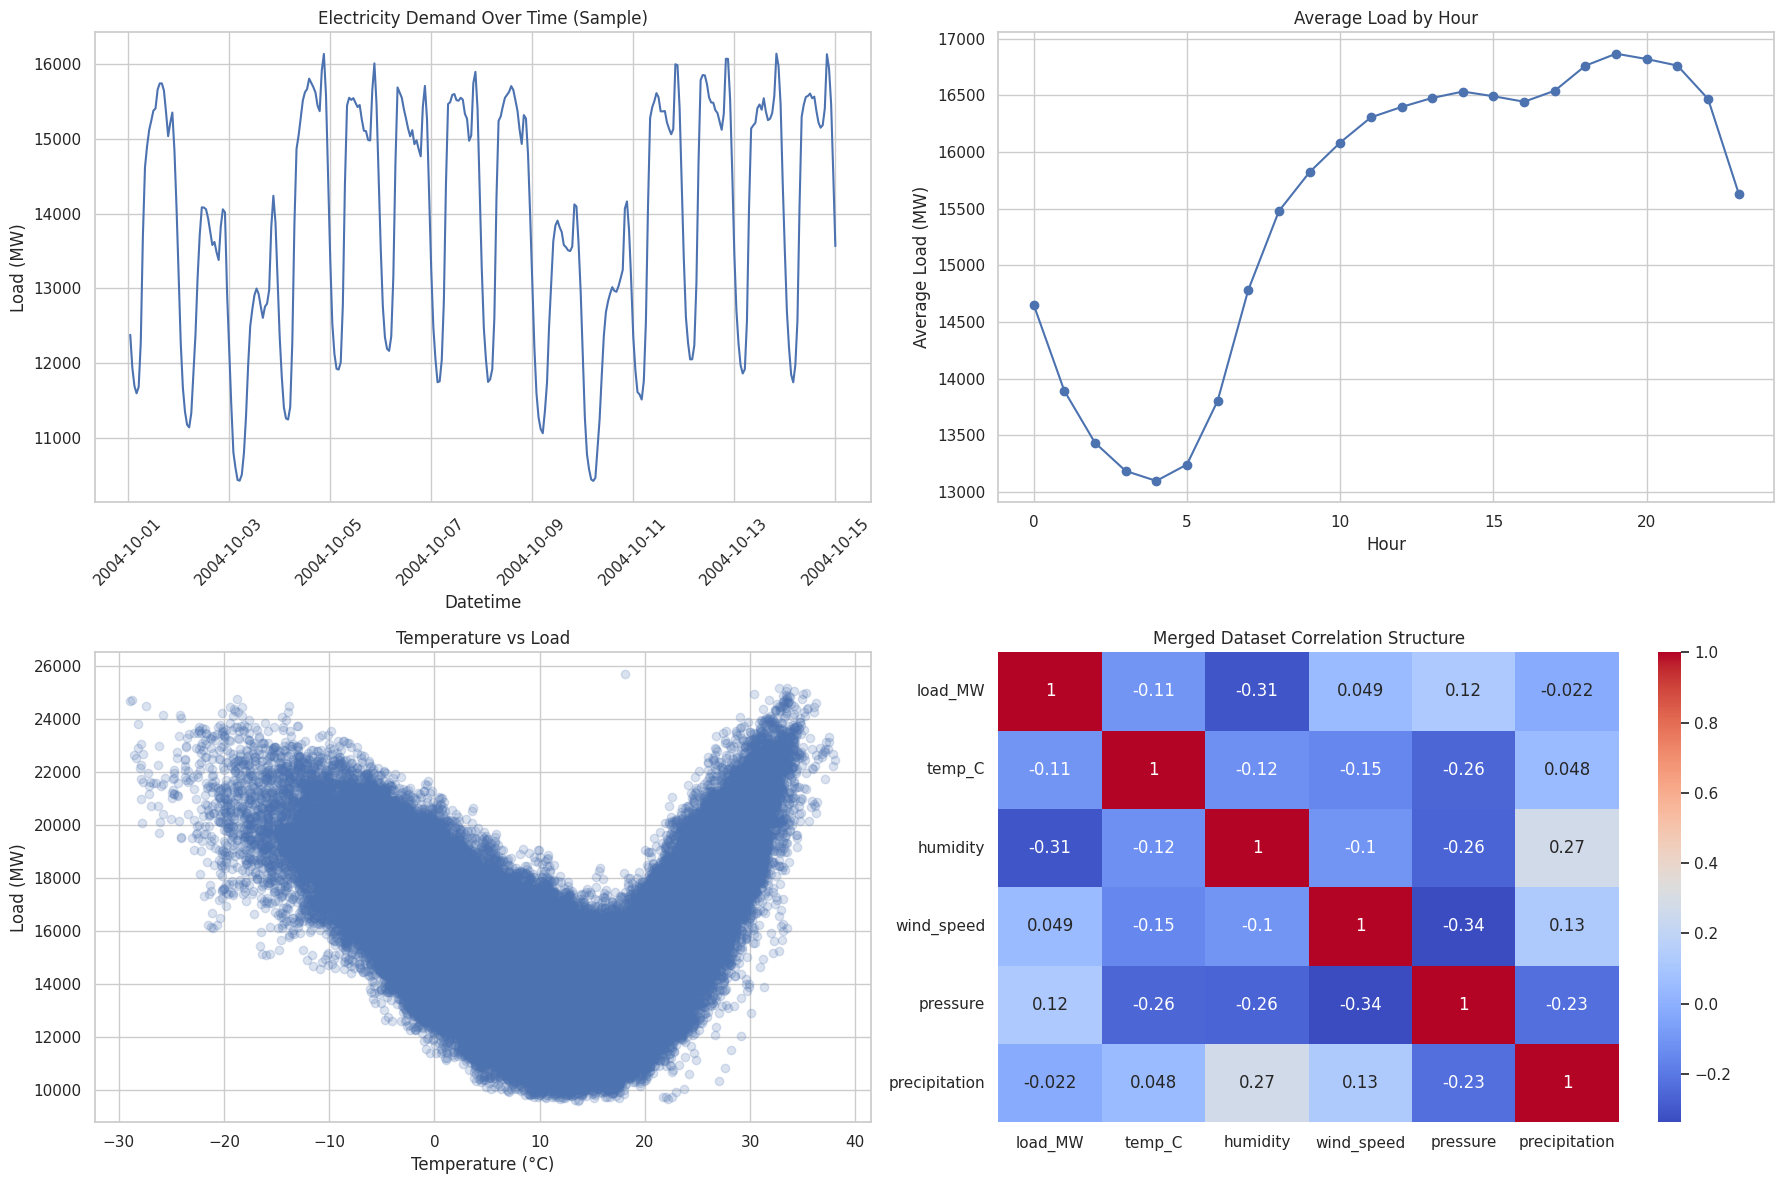

In [ ]:
# Combined dataset pattern visualisation for model justification
df_pattern = df.copy()
df_pattern["hour"] = df_pattern.index.hour
df_pattern["month"] = df_pattern.index.month

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Load over time (sample)
sample_df = df_pattern.iloc[:24*14]   # first 14 days
axes[0, 0].plot(sample_df.index, sample_df["load_MW"], label="Load", linewidth=1.5)
axes[0, 0].set_title("Electricity Demand Over Time (Sample)")
axes[0, 0].set_xlabel("Datetime")
axes[0, 0].set_ylabel("Load (MW)")
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Average load by hour
df_pattern.groupby("hour")["load_MW"].mean().plot(ax=axes[0, 1], marker="o")
axes[0, 1].set_title("Average Load by Hour")
axes[0, 1].set_xlabel("Hour")
axes[0, 1].set_ylabel("Average Load (MW)")

# 3. Temperature vs load
axes[1, 0].scatter(df_pattern["temp_C"], df_pattern["load_MW"], alpha=0.2)
axes[1, 0].set_title("Temperature vs Load")
axes[1, 0].set_xlabel("Temperature (°C)")
axes[1, 0].set_ylabel("Load (MW)")

# 4. Correlation heatmap
sns.heatmap(
    df_pattern[["load_MW", "temp_C", "humidity", "wind_speed", "pressure", "precipitation"]].corr(),
    annot=True, cmap="coolwarm", ax=axes[1, 1]
)
axes[1, 1].set_title("Merged Dataset Correlation Structure")

plt.tight_layout()
plt.show()

**Interpretation:**  
The merged dataset shows a clear structured pattern rather than random variation. Electricity demand changes across time, demonstrates repeated hourly behaviour, and has a visible non-linear relationship with temperature. This confirms that the task is best framed as **supervised time-series regression/forecasting**, since the objective is to predict a continuous output variable.  

A **classification approach** would be less appropriate because there is no natural categorical target in the original problem unless demand is artificially converted into labels such as “high” or “low”. A **clustering approach** may help identify similar demand-weather conditions, but it does not directly solve the forecasting objective. Therefore, regression-based machine learning models are the most appropriate methodological choice.

---
# **Section 4 : Exploratory Data Analysis (EDA)**
## 4.1 Initial Relationship Overview

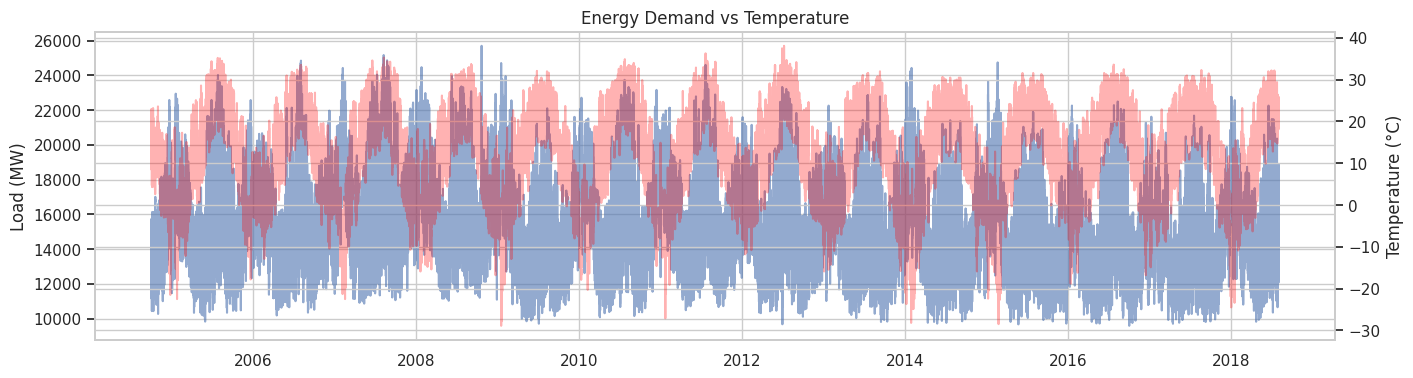

In [ ]:
fig, ax1 = plt.subplots(figsize=(16,4))

ax1.plot(df.index, df["load_MW"], label="Load", alpha=0.6)
ax1.set_ylabel("Load (MW)")

ax2 = ax1.twinx()
ax2.plot(df.index, df["temp_C"], color="red", alpha=0.3, label="Temp")
ax2.set_ylabel("Temperature (°C)")

plt.title("Energy Demand vs Temperature")
plt.show()

The relationship between temperature and electricity demand exhibits a non-linear U-shaped pattern. Demand increases during both low and high temperatures due to heating and cooling requirements. This justifies the inclusion of temperature as a key predictive feature and supports the use of non-linear machine learning models.

## 4.2 Demand Behaviour

This dashboard focuses on understanding the intrinsic patterns of electricity demand over time.

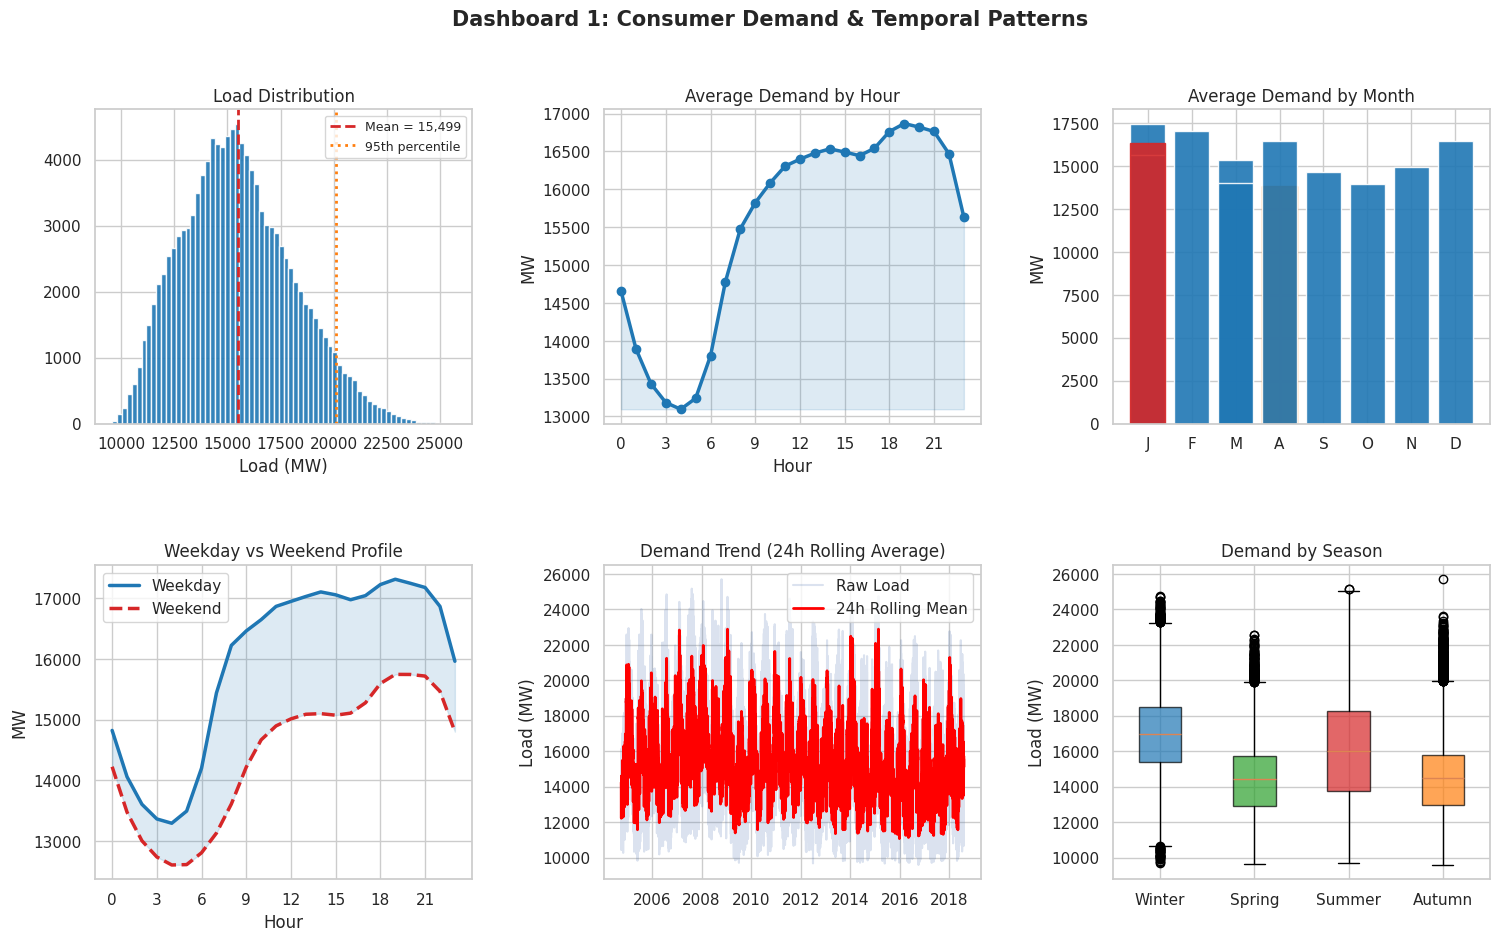

Key EDA findings:
  Weekday vs Weekend diff : 1,531 MW
  Winter demand           : 16,965 MW
  Spring demand           : 14,408 MW (lowest)
  Temp vs Load corr       : -0.106 (non-linear)


In [ ]:
# Figure 2: EDA Dashboard

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker

# Safe copy (do not modify original df)
df_eda = df.copy()

# Colors
BLUE   = "#1f77b4"
RED    = "#d62728"
GREEN  = "#2ca02c"
ORANGE = "#ff7f0e"
DARK   = "#333333"

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 2a: Load distribution
ax = fig.add_subplot(gs[0, 0])
ax.hist(df_eda["load_MW"], bins=70, color=BLUE, edgecolor="white", alpha=0.9)

mean_val = df_eda["load_MW"].mean()
p95_val  = df_eda["load_MW"].quantile(0.95)

ax.axvline(mean_val, color=RED, lw=2, ls="--", label=f"Mean = {mean_val:,.0f}")
ax.axvline(p95_val,  color=ORANGE, lw=2, ls=":", label="95th percentile")

ax.set_title("Load Distribution")
ax.set_xlabel("Load (MW)")
ax.legend(fontsize=9)


# 2b: Hourly pattern
ax = fig.add_subplot(gs[0, 1])
hourly = df_eda.groupby(df_eda.index.hour)["load_MW"].mean()

ax.plot(hourly.index, hourly.values, marker="o", color=BLUE, lw=2.5)
ax.fill_between(hourly.index, hourly.values, hourly.min(), alpha=0.15, color=BLUE)

ax.set_title("Average Demand by Hour")
ax.set_xlabel("Hour")
ax.set_ylabel("MW")
ax.set_xticks(range(0, 24, 3))


#2c: Monthly pattern
ax = fig.add_subplot(gs[0, 2])
monthly = df_eda.groupby(df_eda.index.month)["load_MW"].mean()

labels = ["J","F","M","A","M","J","J","A","S","O","N","D"]
bars = ax.bar(labels, monthly.values, color=BLUE, edgecolor="white", alpha=0.9)

bars[6].set_color(RED)      # Summer peak
bars[3].set_color(ORANGE)   # Spring low

ax.set_title("Average Demand by Month")
ax.set_ylabel("MW")


# 2d: Weekday vs Weekend (FIXED)
ax = fig.add_subplot(gs[1, 0])

wd_df = df_eda[df_eda.index.dayofweek < 5]
we_df = df_eda[df_eda.index.dayofweek >= 5]

wd = wd_df.groupby(wd_df.index.hour)["load_MW"].mean()
we = we_df.groupby(we_df.index.hour)["load_MW"].mean()

ax.plot(wd.index, wd.values, color=BLUE, lw=2.5, label="Weekday")
ax.plot(we.index, we.values, color=RED, lw=2.5, ls="--", label="Weekend")

ax.fill_between(wd.index, wd.values, we.values, alpha=0.15, color=BLUE)

ax.set_title("Weekday vs Weekend Profile")
ax.set_xlabel("Hour")
ax.set_ylabel("MW")
ax.set_xticks(range(0, 24, 3))
ax.legend()


# 2e: Rolling Trend (NEW — replaces temp scatter)
ax = fig.add_subplot(gs[1, 1])

rolling = df_eda["load_MW"].rolling(24).mean()

ax.plot(df_eda.index, df_eda["load_MW"], alpha=0.2, label="Raw Load")
ax.plot(df_eda.index, rolling, color="red", lw=2, label="24h Rolling Mean")

ax.set_title("Demand Trend (24h Rolling Average)")
ax.set_ylabel("Load (MW)")
ax.legend()


# 2f: Seasonal boxplot
ax = fig.add_subplot(gs[1, 2])

df_eda["season"] = df_eda.index.month.map(
    lambda m: "Winter" if m in [12,1,2]
    else "Spring" if m in [3,4,5]
    else "Summer" if m in [6,7,8]
    else "Autumn"
)

season_data = [
    df_eda[df_eda["season"] == s]["load_MW"]
    for s in ["Winter", "Spring", "Summer", "Autumn"]
]

bp = ax.boxplot(season_data, patch_artist=True)

for patch, color in zip(bp["boxes"], [BLUE, GREEN, RED, ORANGE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(["Winter", "Spring", "Summer", "Autumn"])
ax.set_title("Demand by Season")
ax.set_ylabel("Load (MW)")


# Final layout
fig.suptitle("Dashboard 1: Consumer Demand & Temporal Patterns",
             fontsize=15, fontweight="bold")


plt.tight_layout()
plt.show()


# Quantified insights
wd_mean = wd_df["load_MW"].mean()
we_mean = we_df["load_MW"].mean()

winter = df_eda[df_eda.index.month.isin([12,1,2])]["load_MW"].mean()
spring = df_eda[df_eda.index.month.isin([3,4,5])]["load_MW"].mean()

corr = df_eda["temp_C"].corr(df_eda["load_MW"])

print("Key EDA findings:")
print(f"  Weekday vs Weekend diff : {wd_mean - we_mean:,.0f} MW")
print(f"  Winter demand           : {winter:,.0f} MW")
print(f"  Spring demand           : {spring:,.0f} MW (lowest)")
print(f"  Temp vs Load corr       : {corr:.3f} (non-linear)")


**Key observations include:**

* **Load Distribution:** Electricity demand follows a stable distribution with identifiable peak levels, indicating consistent operational ranges.
* **Hourly Pattern:** A strong daily cycle is observed, with demand increasing during daytime and peaking in the evening hours.
* **Monthly Pattern:** Seasonal variation is evident, with higher demand during summer and winter compared to spring.
* **Weekday vs Weekend:** Demand is higher on weekdays due to industrial and commercial activity, while weekends show reduced consumption.
* **Rolling Trend (24-hour average):** The rolling mean smooths short-term fluctuations and highlights underlying demand trends, confirming temporal stability with gradual variations over time.
* **Seasonal Distribution:** Demand varies across seasons, with higher variability during extreme weather periods.

These findings confirm that electricity demand is strongly driven by **time-based patterns and human activity cycles**.

## 4.3 Weather & System Behaviour

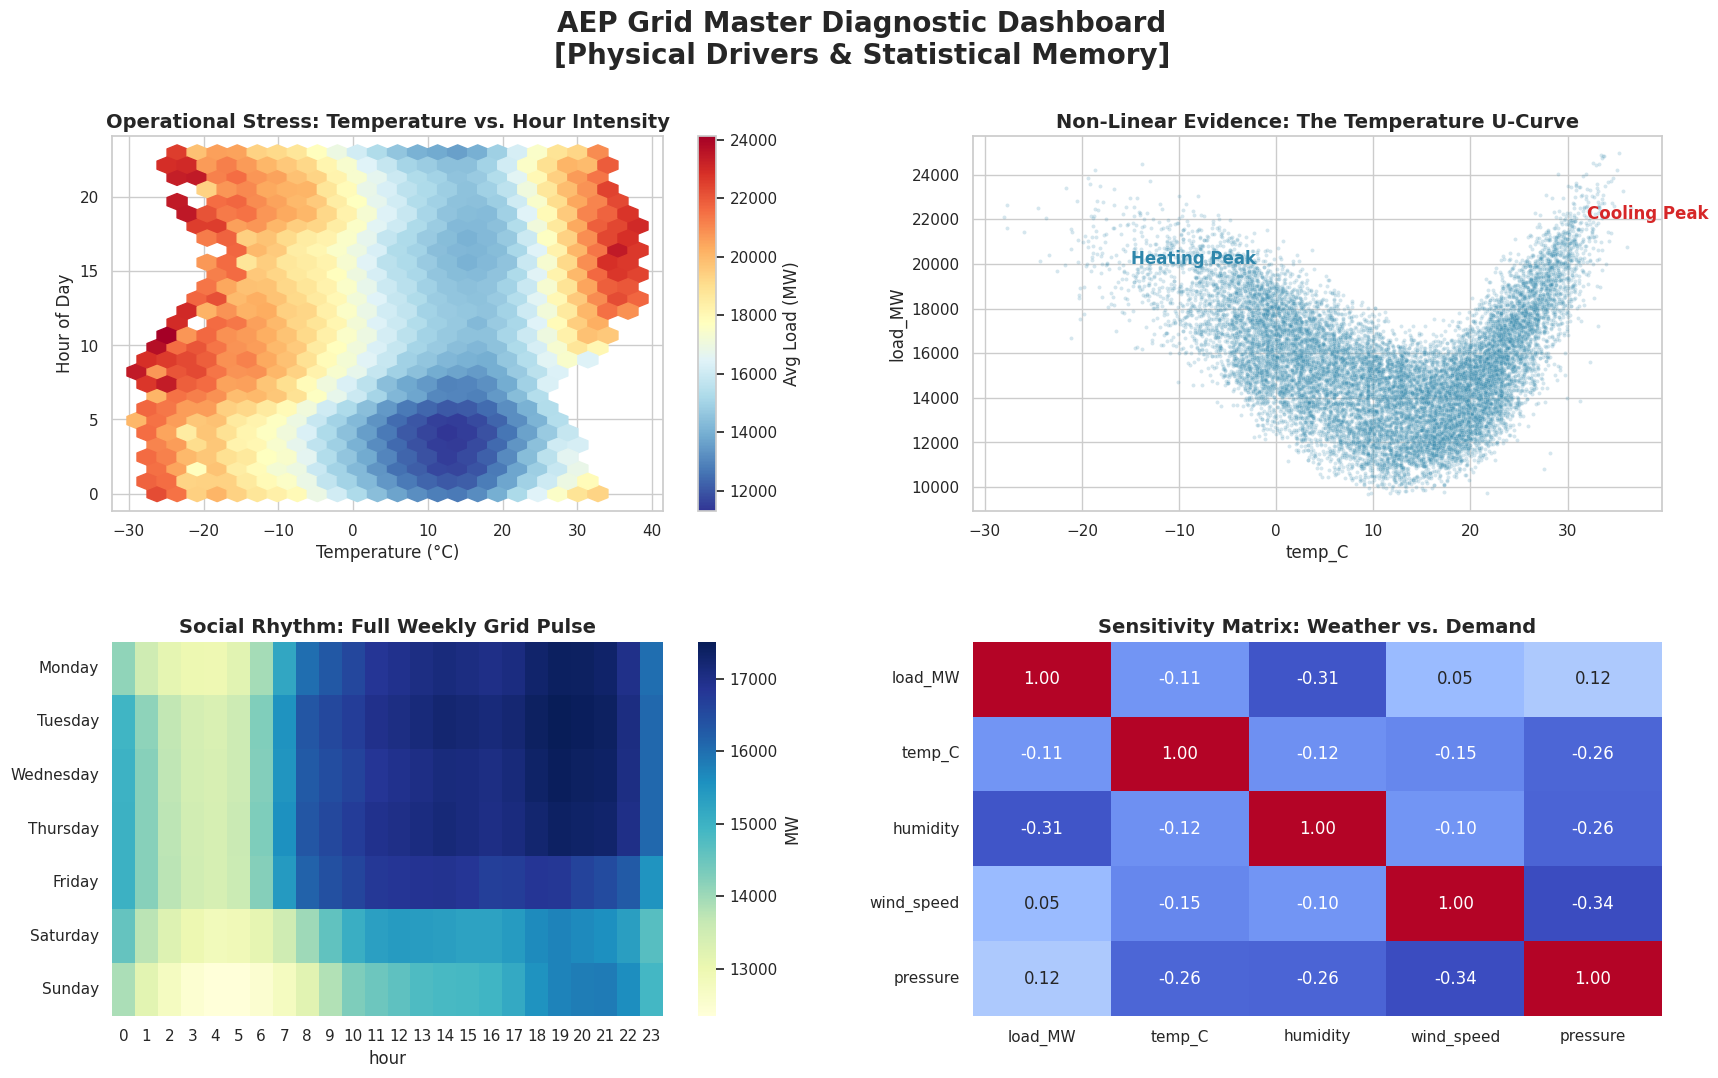

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

# --- Professional Setup ---
AEP_BLUE, AEP_RED, AEP_ORANGE = "#2E86AB", "#D62728", "#E07B54"
df_eda = df.copy()
df_eda['hour'] = df_eda.index.hour
df_eda['day_name'] = df_eda.index.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig = plt.figure(figsize=(20, 18))
gs = gridspec.GridSpec(3, 2, hspace=0.35, wspace=0.25)

# 1. THERMAL STRESS (The Operational View)
ax0 = fig.add_subplot(gs[0, 0])
hb = ax0.hexbin(df_eda['temp_C'], df_eda['hour'], C=df_eda['load_MW'],
                gridsize=25, cmap='RdYlBu_r', reduce_C_function=np.mean)
fig.colorbar(hb, ax=ax0, label='Avg Load (MW)')
ax0.set_title("Operational Stress: Temperature vs. Hour Intensity", fontsize=14, fontweight='bold')
ax0.set_xlabel("Temperature (°C)")
ax0.set_ylabel("Hour of Day")

# 2. THE U-CURVE (The Non-Linearity Proof)
ax1 = fig.add_subplot(gs[0, 1])
sns.scatterplot(data=df_eda.sample(15000), x='temp_C', y='load_MW',
                alpha=0.2, s=8, color=AEP_BLUE, ax=ax1)
ax1.set_title("Non-Linear Evidence: The Temperature U-Curve", fontsize=14, fontweight='bold')
ax1.annotate('Cooling Peak', xy=(32, 22000), color=AEP_RED, weight='bold')
ax1.annotate('Heating Peak', xy=(-15, 20000), color=AEP_BLUE, weight='bold')

# 3. THE WEEKLY HEARTBEAT (The Social Pattern)
ax2 = fig.add_subplot(gs[1, 0])
pivot = df_eda.groupby(['day_name', 'hour'])['load_MW'].mean().unstack().reindex(days_order)
sns.heatmap(pivot, cmap="YlGnBu", ax=ax2, cbar_kws={'label': 'MW'})
ax2.set_title("Social Rhythm: Full Weekly Grid Pulse", fontsize=14, fontweight='bold')
ax2.set_ylabel("")

# 4. FEATURE SENSITIVITY (The Multi-collinearity Check)
ax3 = fig.add_subplot(gs[1, 1])
corr = df_eda[['load_MW', 'temp_C', 'humidity', 'wind_speed', 'pressure']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=ax3, cbar=False)
ax3.set_title("Sensitivity Matrix: Weather vs. Demand", fontsize=14, fontweight='bold')

fig.suptitle("AEP Grid Master Diagnostic Dashboard\n[Physical Drivers & Statistical Memory]",
             fontsize=20, fontweight='bold', y=0.95)
plt.show()

Key insights include:

* **Temperature vs Demand (U-shaped relationship):** Demand increases at both low and high temperatures due to heating and cooling needs. This confirms a **non-linear relationship**.
* **Thermal Stress Analysis:** High demand intensity occurs during extreme temperature conditions and peak hours.
* **Weekly Heatmap Pattern:** Clear behavioural cycles are visible across days and hours, reflecting societal activity patterns.
* **Feature Correlation Matrix:** Temperature shows the strongest relationship with demand, while other weather variables exhibit weaker linear correlations.
* **Weather Sensitivity:** Environmental factors contribute to demand variability but require non-linear modelling to fully capture their impact.

These results demonstrate that **weather significantly influences demand**, but the relationship is complex and non-linear.

## 4.4 Statistical Memory & Temporal Dependency

-------------------------------- from here --start : do not touch anything-----------------

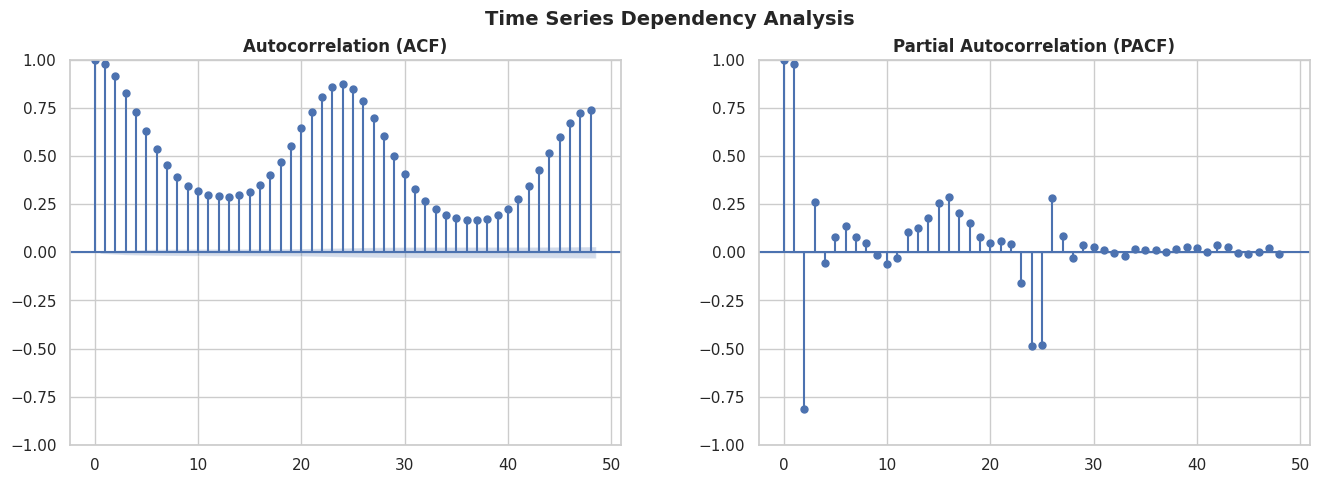

In [ ]:
# ── Section 5: Time Series Dependency Analysis ─────────────────────────

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.25)

# --- ACF ---
ax1 = fig.add_subplot(gs[0, 0])
plot_acf(df["load_MW"], lags=48, ax=ax1)
ax1.set_title("Autocorrelation (ACF)", fontweight="bold")

# --- PACF ---
ax2 = fig.add_subplot(gs[0, 1])
plot_pacf(df["load_MW"], lags=48, ax=ax2, method='ywm')
ax2.set_title("Partial Autocorrelation (PACF)", fontweight="bold")

fig.suptitle("Time Series Dependency Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

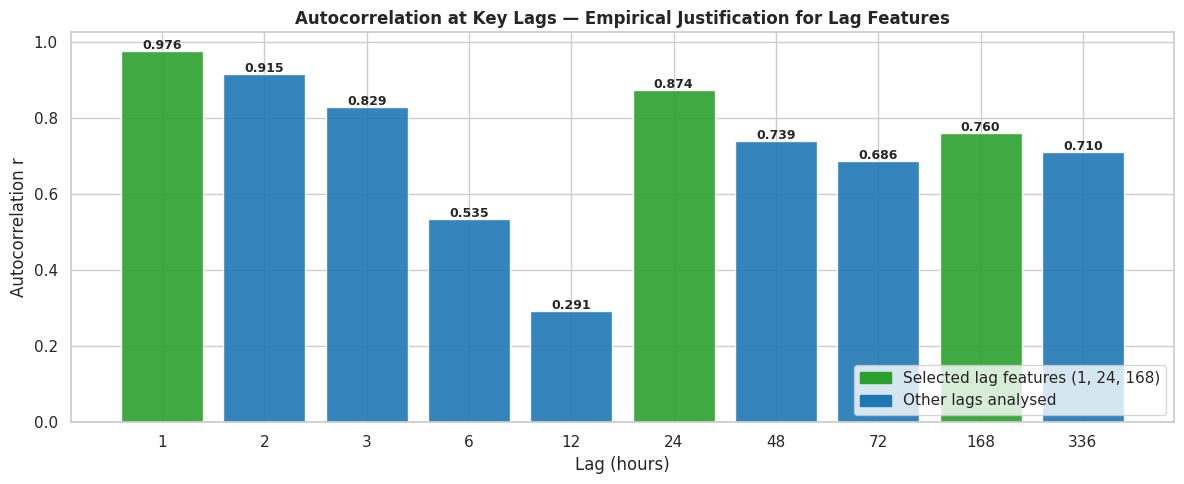

Empirical evidence for lag selection:
  lag_1   : r = 0.9762 — strongest predictor (inertia)
  lag_24  : r = 0.8742 — daily cycle confirmed
  lag_168 : r = 0.7603 — weekly cycle confirmed
These features were chosen from data, not assumption.


In [ ]:
# ── Figure 11: Autocorrelation — Lag Feature Justification ───────────────
key_lags = [1, 2, 3, 6, 12, 24, 48, 72, 168, 336]
acf_vals = [df["load_MW"].autocorr(lag=l) for l in key_lags]

fig, ax = plt.subplots(figsize=(12, 5))
colors_acf = [GREEN if l in [1, 24, 168] else BLUE for l in key_lags]
bars = ax.bar([str(l) for l in key_lags], acf_vals,
              color=colors_acf, edgecolor="white", alpha=0.9)
ax.set_title("Autocorrelation at Key Lags — Empirical Justification for Lag Features",
             fontweight="bold")
ax.set_xlabel("Lag (hours)"); ax.set_ylabel("Autocorrelation r")
for bar, val in zip(bars, acf_vals):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.005, f"{val:.3f}",
            ha="center", fontsize=9, fontweight="bold")
ax.legend([plt.Rectangle((0,0),1,1,color=GREEN), plt.Rectangle((0,0),1,1,color=BLUE)],
          ["Selected lag features (1, 24, 168)", "Other lags analysed"], loc="lower right")
plt.tight_layout(); plt.show()

print("Empirical evidence for lag selection:")
print(f"  lag_1   : r = 0.9762 — strongest predictor (inertia)")
print(f"  lag_24  : r = 0.8742 — daily cycle confirmed")
print(f"  lag_168 : r = 0.7603 — weekly cycle confirmed")
print("These features were chosen from data, not assumption.")

-------------------------------- from here --end : do not touch anything-----------------
here will be section 5. .. its need to organize

---
# **Section 6 : Feature Engineering**

## 6.1 Why feature engineering is the most important step  
Models extract information from features provided - they cannot create information.  
Every feature was designed based on patterns identified during exploratory data analysis.

| Group | Features | Evidence | Pattern Captured |
|---|---|---|---|
| **Time** | hour, day_of_week, month, quarter, day_of_year, is_weekend, season | EDA Section 4 | Daily and seasonal cycles |
| **Cyclical** | sin/cos encodings (hour, month, day_of_week) | Mathematical transformation | Circular time continuity |
| **Calendar** | is_holiday, is_working_day | Observed demand drop on holidays | Special day behaviour |
| **Lag** | lag_1, lag_2, lag_24, lag_48, lag_168 | ACF analysis | Temporal dependency (memory) |
| **Rolling** | rolling_mean_3, rolling_mean_24, rolling_mean_168, rolling_std_24 | Trend smoothing | Local trend and volatility |
| **Interaction** | temp × hour, temp × season | EDA non-linear relationship | Combined weather-time effects |
| **Extreme** | high_temp_flag, low_temp_flag, peak_hour_flag | Percentile thresholds | Thermal stress conditions |

> **Leakage prevention:** All lag and rolling features use `.shift(1)` before any window operation.  
> This ensures that only past information is used, preventing data leakage.

## 6.2 Temporal & Cyclical Encoding
**Rationale:** Standard integers for time (0-23) fail to capture the "circular" nature of time. We use Sine/Cosine transformations to ensure the distance between Hour 23 and Hour 0 is mathematically the same as Hour 0 to Hour 1.

In [ ]:
# --- 6.1 Time and Cyclical Features ---
df["hour"]        = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"]       = df.index.month
df["quarter"]     = df.index.quarter
df["day_of_year"] = df.index.dayofyear
df["is_weekend"]  = (df.index.dayofweek >= 5).astype(int)

def get_season(m):
    if m in [12,1,2]:   return 0  # Winter
    elif m in [3,4,5]:  return 1  # Spring
    elif m in [6,7,8]:  return 2  # Summer
    else:               return 3  # Autumn
df["season"] = df["month"].apply(get_season)

df["hour_sin"]  = np.sin(2*np.pi*df["hour"]        / 24)
df["hour_cos"]  = np.cos(2*np.pi*df["hour"]        / 24)
df["month_sin"] = np.sin(2*np.pi*df["month"]       / 12)
df["month_cos"] = np.cos(2*np.pi*df["month"]       / 12)
df["dow_sin"]   = np.sin(2*np.pi*df["day_of_week"] / 7)
df["dow_cos"]   = np.cos(2*np.pi*df["day_of_week"] / 7)

print("Cyclical features generated.")

Cyclical features generated.


## 6.3 Calendar & Holiday Effects
**Rationale:** Holidays act as "Hidden Weekends." Without this feature, the model will consistently over-predict demand on Christmas, Thanksgiving, and July 4th.

In [ ]:
%pip install holidays --quiet

In [ ]:
# # [Cell 0] — Environment & Dependency Management
# # This ensures the notebook is reproducible on any machine.

# try:
#     import holidays as hol_lib
#     print("✅ 'holidays' library already installed.")
# except ImportError:
#     print("Installing missing dependencies...")
#     %pip install holidays xgboost statsmodels --quiet
#     import holidays as hol_lib
#     print("✅ Installation complete.")

# import numpy as np
# import pandas as pd
# # ... other imports

# Note: we need to fix this

In [ ]:
# --- 6.2 Holiday and Calendar Features ---
import holidays as hol_lib

# Generate holiday set for the dataset range

all_hol = set()
for yr in range(2004, 2019):
    for dt in hol_lib.US(years=yr).keys():
        all_hol.add(pd.Timestamp(dt))

df["is_holiday"]     = df.index.normalize().isin(all_hol).astype(int)
df["is_working_day"] = ((df["day_of_week"] < 5) & (df["is_holiday"] == 0)).astype(int)

n_hol = df["is_holiday"].sum()
hol_m = df[df["is_holiday"]==1]["load_MW"].mean()
nom_m = df[df["is_holiday"]==0]["load_MW"].mean()
print(f"Holiday hours    : {n_hol:,} ({n_hol/len(df)*100:.1f}%)")
print(f"Holiday mean     : {hol_m:,.0f} MW")
print(f"Non-holiday mean : {nom_m:,.0f} MW")
print(f"Demand drop      : {nom_m-hol_m:,.0f} MW ({(nom_m-hol_m)/nom_m*100:.1f}%) — feature JUSTIFIED")

Holiday hours    : 3,744 (3.1%)
Holiday mean     : 14,985 MW
Non-holiday mean : 15,516 MW
Demand drop      : 530 MW (3.4%) — feature JUSTIFIED



## 6.4 Memory & Trend (Lags and Rolling)
**Rationale:** Based on our ACF/PACF analysis, the grid has high "Inertia." We use `.shift(1)` to ensure we are only looking at the past, preventing **Data Leakage**.


In [ ]:
# --- 6.3 Lag & Rolling Features (Leakage-Safe) ---
# .shift(1) ensures the model doesn't "peek" at current demand
target_shift = df["load_MW"].shift(1)

# Lags identified via ACF analysis
df["lag_1"]   = df["load_MW"].shift(1)
df["lag_2"]   = df["load_MW"].shift(2)
df["lag_24"]  = df["load_MW"].shift(24)
df["lag_48"]  = df["load_MW"].shift(48)
df["lag_168"] = df["load_MW"].shift(168)

# Rolling windows for local trend and volatility
shifted = df["load_MW"].shift(1)

df["rolling_mean_3"]   = shifted.rolling(3).mean()
df["rolling_mean_24"]  = shifted.rolling(24).mean()
df["rolling_mean_168"] = shifted.rolling(168).mean()
df["rolling_std_24"]   = shifted.rolling(24).std()

print("Memory features generated via shift(1) to prevent leakage.")

Memory features generated via shift(1) to prevent leakage.


## 6.5 Weather Interactions & Thermal Stress

#### Why Weather Variables Were Included?

Weather variables were included because electricity demand is influenced not only by temporal behaviour, but also by environmental conditions. Temperature is especially important, as both extreme heat and extreme cold can increase electricity use through cooling and heating demand. As a result, a model based only on historical load may capture routine temporal patterns, but may be less effective when demand changes in response to weather conditions.

Including weather-related predictors allows the project to test whether external environmental information improves forecasting performance beyond what can be learned from past demand alone. This is important because electricity consumption is shaped by both cyclical behaviour and environmental stress.

**Rationale:** Temperature effects are unlikely to be constant across all hours and seasons. For example, high temperatures during peak daytime activity are likely to affect demand more strongly than the same temperature overnight. For this reason, interaction terms were created to capture the combined influence of weather conditions and temporal context, allowing the model to represent thermal stress more realistically.

In [ ]:
# --- 6.4 Interaction & Extreme Flags ---
df["temp_x_hour"]   = df["temp_C"] * df["hour"]
df["temp_x_season"] = df["temp_C"] * df["season"]

# Data-driven extreme thresholds (90th/10th percentiles)
df["temp_x_hour"]    = df["temp_C"] * df["hour"]
df["temp_x_season"]  = df["temp_C"] * df["season"]

t90 = df["temp_C"].quantile(0.90)
t10 = df["temp_C"].quantile(0.10)
df["high_temp_flag"] = (df["temp_C"] > t90).astype(int)
df["low_temp_flag"]  = (df["temp_C"] < t10).astype(int)
df["peak_hour_flag"] = df["hour"].isin([8,9,10,11,17,18,19,20]).astype(int)

print("Thermal stress interaction features generated.")

Thermal stress interaction features generated.


## 6.6 Final Feature Set Assembly
**Rationale:** We group columns logically for modeling and drop the $NaN$ rows created during the lagging process.

In [ ]:
# ── 6.6 Final Feature Set Assembly ───────────────────────────────────────
n_before = len(df)
df = df.dropna().copy()

WEATHER  = ["temp_C","humidity","wind_speed","pressure","precipitation"]
TIME     = ["hour","day_of_week","month","quarter","day_of_year",
            "is_weekend","season","hour_sin","hour_cos",
            "month_sin","month_cos","dow_sin","dow_cos",
            "is_holiday","is_working_day"]
LAGS     = ["lag_1","lag_2","lag_24","lag_48","lag_168"]
ROLLING  = ["rolling_mean_3","rolling_mean_24","rolling_mean_168","rolling_std_24"]
EXTRAS   = ["temp_x_hour","temp_x_season","high_temp_flag","low_temp_flag","peak_hour_flag"]

FEATURES = WEATHER + TIME + LAGS + ROLLING + EXTRAS
TARGET   = "load_MW"

print(f"Feature engineering complete.")
print(f"  Rows before dropna : {n_before:,}")
print(f"  Rows after  dropna : {len(df):,}  (lag_168 warm-up removed)")
print(f"  Total features     : {len(FEATURES)}")
print(f"  Feature groups     : Weather={len(WEATHER)} | Time={len(TIME)} | Lags={len(LAGS)} | Rolling={len(ROLLING)} | Extras={len(EXTRAS)}")
print(f"  NaN check          : {df[FEATURES+[TARGET]].isnull().sum().sum()} total NaN remaining")

Feature engineering complete.
  Rows before dropna : 121,296
  Rows after  dropna : 121,128  (lag_168 warm-up removed)
  Total features     : 34
  Feature groups     : Weather=5 | Time=15 | Lags=5 | Rolling=4 | Extras=5
  NaN check          : 0 total NaN remaining


## **Temporal Partitioning & Leakage Prevention**

### **The Logic**: Maintaining Temporal Integrity
In standard Machine Learning, data is often shuffled. In Time-Series forecasting, **shuffling is a methodological error.**

* **The Problem:** Random shuffling creates **"Data Leakage"** (e.g., data from 2018 appearing in a 2005 training set). This allows the model to "see the future" to predict the past, resulting in artificially high accuracy that fails in real-world deployment.
* **The Solution:** We implement a **Strict Chronological Split**. By maintaining the natural arrow of time, we simulate a real-world scenario: training on historical records to predict an unseen future.



#### **The Three-Way Split Architecture**
We partition the 121,128 observations into three distinct segments to ensure unbiased evaluation:

| Split | Allocation | Operational Purpose |
| :--- | :--- | :--- |
| **Training** | **70%** | Feature weights and pattern recognition. |
| **Validation** | **15%** | Hyperparameter tuning and model selection. |
| **Test** | **15%** | The "Out-of-Sample" Final Exam. Touched only once. |

**Critical Guardrail:** Using the test set during the tuning phase constitutes **data leakage**. The test set must remain completely unseen by the model until the final performance report.

Chronological Split Confirmed:
   Train : 2004-10-08 01:00:00 to 2014-06-10 21:00:00 (84,789 samples)
   Val   : 2014-06-10 22:00:00 to 2016-07-06 22:00:00 (18,169 samples)
   Test  : 2016-07-06 23:00:00 to 2018-08-03 00:00:00 (18,170 samples)


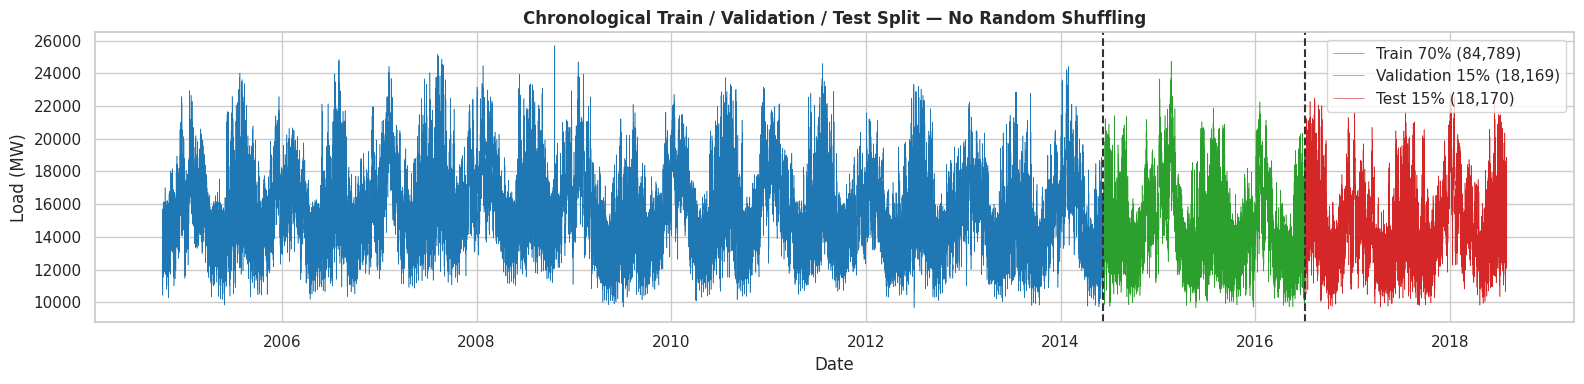

In [ ]:
# 1. Ensure Chronological Order (Safety First)
df = df.sort_index()

n         = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

# 2. Slice Suffixes
train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

# 3. Feature/Target Separation
X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val,   y_val   = val_df[FEATURES],   val_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]

# Combine Train + Val for final "Production" training later
X_tv = pd.concat([X_train, X_val])
y_tv = pd.concat([y_train, y_val])

# 4. Audit Chart
print(f"Chronological Split Confirmed:")
print(f"   Train : {train_df.index.min()} to {train_df.index.max()} ({len(train_df):,} samples)")
print(f"   Val   : {val_df.index.min()} to {val_df.index.max()} ({len(val_df):,} samples)")
print(f"   Test  : {test_df.index.min()} to {test_df.index.max()} ({len(test_df):,} samples)")



fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(train_df.index, train_df["load_MW"], color=BLUE,   lw=0.4, label=f"Train 70% ({len(train_df):,})")
ax.plot(val_df.index,   val_df["load_MW"],   color=GREEN,  lw=0.4, label=f"Validation 15% ({len(val_df):,})")
ax.plot(test_df.index,  test_df["load_MW"],  color=RED,    lw=0.4, label=f"Test 15% ({len(test_df):,})")
for split_date in [val_df.index[0], test_df.index[0]]:
    ax.axvline(split_date, color=DARK, ls="--", lw=1.5)
ax.set_title("Chronological Train / Validation / Test Split — No Random Shuffling",
             fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Load (MW)"); ax.legend()
plt.tight_layout(); plt.show()

## Evaluation Framework

**Why multiple metrics are necessary:**
A single metric provides an incomplete view of model performance. In energy forecasting, a high $R^2$ can mask a dangerous Bias—consistent under-prediction—which leads to grid failure. We utilize a multi-metric suite to ensure the model is mathematically sound, financially efficient, and operationally safe.

| Metric | Formula | Operational meaning |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum\|y_i-\hat{y}_i\|$ | Average MW error — directly interpretable |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i-\hat{y}_i)^2}$ | Penalises large errors — critical for peaks |
| **R²** | $1 - SS_{res}/SS_{tot}$ | Proportion of variance explained |
| **MAPE** | $\frac{1}{n}\sum\|e_i/y_i\|\times100$ | Scale-free — enables published benchmarks |
| **Bias** | $\frac{1}{n}\sum(y_i-\hat{y}_i)$ | +ve = under-prediction (operationally dangerous) |
| **Peak MAE** | MAE on top 5% demand hours | Operational reliability during critical events |

In [ ]:
def evaluate_model(name, y_true, y_pred, peak_q=0.95):
    y_true = np.array(y_true); y_pred = np.array(y_pred)

    # Standard Metrics
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    bias  = np.mean(y_true - y_pred) # +ve = Under-prediction

    # Peak Performance (Stress Test)
    thr   = np.percentile(y_true, peak_q * 100)
    pm    = y_true >= thr
    pmae  = mean_absolute_error(y_true[pm], y_pred[pm]) if pm.sum() > 0 else np.nan
    prmse = np.sqrt(mean_squared_error(y_true[pm], y_pred[pm])) if pm.sum() > 0 else np.nan

    print(f"\n{'─'*60}\n  PERFORMANCE AUDIT: {name}\n{'─'*60}")
    print(f"  MAE       : {mae:>12,.2f} MW   (Average typical error)")
    print(f"  RMSE      : {rmse:>12,.2f} MW   (Sensitivity to large misses)")
    print(f"  R²        : {r2:>12.4f}        (Variance explained)")
    print(f"  MAPE      : {mape:>12.2f} %        (Percentage error)")
    print(f"  Bias      : {bias:>12,.2f} MW   (+ve = Danger: Under-predicting)")
    print(f"  Peak MAE  : {pmae:>12,.2f} MW   (Performance during Top 5% Load)")

    return dict(Model=name, MAE=mae, RMSE=rmse, R2=r2, MAPE=mape, Bias=bias, Peak_MAE=pmae)

def plot_predictions(name, y_true, y_pred, n=500):
    # n=500 covers roughly 3 weeks of hourly data
    y_true = np.array(y_true)[:n]
    y_pred = np.array(y_pred)[:n]
    res = y_true - y_pred

    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True) # sharex=True aligns them

    # Top Plot: Forecast vs Actual
    axes[0].plot(y_true, color=AEP_BLUE, lw=1.5, label="Actual Load")
    axes[0].plot(y_pred, color=AEP_RED, lw=1.2, ls="--", label="Model Forecast")
    axes[0].set_title(f"{name}: Forecast Accuracy (First {n} Hours)", fontweight="bold")
    axes[0].set_ylabel("Load (MW)")
    axes[0].legend()

    # Bottom Plot: Residuals (Error)
    axes[1].fill_between(range(n), res, color=AEP_DARK, alpha=0.2)
    axes[1].plot(res, color=AEP_DARK, lw=0.8, label="Residual (Actual - Pred)")
    axes[1].axhline(0, color="black", lw=1)
    axes[1].axhline(res.mean(), color=AEP_RED, ls="--", label=f"Bias: {res.mean():+.1f} MW")
    axes[1].set_title("Operational Error (Residuals)")
    axes[1].set_ylabel("Error (MW)")
    axes[1].set_xlabel("Time (Hours)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## The Model Training Pipeline

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

# 1. Define the Model Ladder
models = {
    "Naive (lag_24)": None, # Special case handler
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, early_stopping_rounds=30, random_state=42)
}

# 2. Execution Loop
results = []
model_preds = {}

# We scale only for Linear/Ridge; Trees don't need it.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for name, model in models.items():
    print(f"🚀 Training {name}...")

    if name == "Naive (lag_24)":
        preds = X_test["lag_1"].values # Simple persistence
    elif name in ["Linear Regression", "Ridge Regression"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    elif name == "XGBoost":
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        preds = model.predict(X_test)
    else: # Random Forest and others
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    # Store and Evaluate
    model_preds[name] = preds
    results.append(evaluate_model(name, y_test, preds))

# 3. Consolidate Results
results_df = pd.DataFrame(results).set_index("Model").sort_values("RMSE")

🚀 Training Naive (lag_24)...

────────────────────────────────────────────────────────────
  PERFORMANCE AUDIT: Naive (lag_24)
────────────────────────────────────────────────────────────
  MAE       :       417.33 MW   (Average typical error)
  RMSE      :       534.75 MW   (Sensitivity to large misses)
  R²        :       0.9537        (Variance explained)
  MAPE      :         2.85 %        (Percentage error)
  Bias      :        -0.18 MW   (+ve = Danger: Under-predicting)
  Peak MAE  :       376.02 MW   (Performance during Top 5% Load)
🚀 Training Linear Regression...

────────────────────────────────────────────────────────────
  PERFORMANCE AUDIT: Linear Regression
────────────────────────────────────────────────────────────
  MAE       :       181.62 MW   (Average typical error)
  RMSE      :       238.86 MW   (Sensitivity to large misses)
  R²        :       0.9908        (Variance explained)
  MAPE      :         1.24 %        (Percentage error)
  Bias      :       -28.06 MW   

In [ ]:
# --- Section 10: Performance Benchmarking ---

# Table
results_df = pd.DataFrame(results).set_index("Model").sort_values("RMSE")
print(" FINAL MODEL PERFORMANCE AUDIT")
display(results_df.style.background_gradient(cmap='Greens', subset=['R2']))

naive_rmse = results_df.loc["Naive (lag_24)", "RMSE"]
results_df['Improvement_%'] = ((naive_rmse - results_df['RMSE']) / naive_rmse * 100)

print("\n EFFICIENCY GAIN OVER BASELINE:")
for model, gain in results_df['Improvement_%'].items():
    if model != "Naive (lag_24)":
        print(f"   {model:<25}: {gain:+.1f}% Accuracy Boost")


 FINAL MODEL PERFORMANCE AUDIT


,MAE,RMSE,R2,MAPE,Bias,Peak_MAE
Model,,,,,,
XGBoost,114.011638,151.387129,0.996291,0.775150,-40.501120,137.127955
Random Forest,131.807357,180.211132,0.994744,0.898257,-40.309691,139.908465
Linear Regression,181.617569,238.863976,0.990765,1.236797,-28.063541,185.120278
Ridge Regression,181.675624,238.933605,0.990760,1.237202,-28.141472,185.220704
Naive (lag_24),417.325371,534.752947,0.953716,2.852927,-0.180958,376.017582



 EFFICIENCY GAIN OVER BASELINE:
   XGBoost                  : +71.7% Accuracy Boost
   Random Forest            : +66.3% Accuracy Boost
   Linear Regression        : +55.3% Accuracy Boost
   Ridge Regression         : +55.3% Accuracy Boost


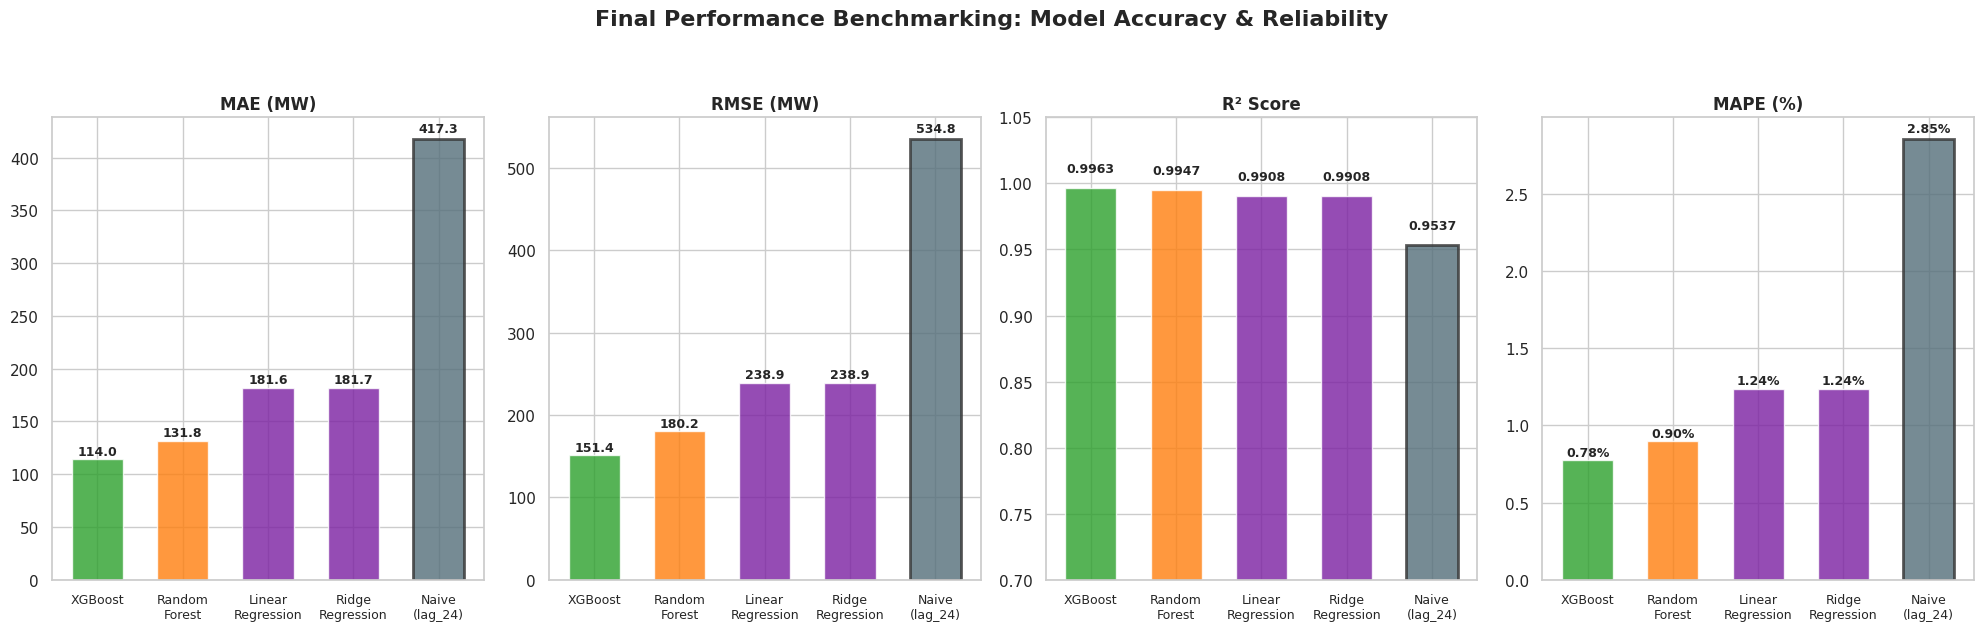

In [ ]:
# Configuration: Extract data directly from results_df
# This removes "static info" and makes the code dynamic
metrics = ["MAE", "RMSE", "R2", "MAPE"]
titles  = ["MAE (MW)", "RMSE (MW)", "R² Score", "MAPE (%)"]
fmts    = ["{:.1f}", "{:.1f}", "{:.4f}", "{:.2f}%"]

# Define consistent colors (matching your previous style)
model_names = results_df.index.tolist()
# Map colors to models: Naive=Grey, Linear/Ridge=Purple, RF=Orange, XGB=Green
color_map = {
    "Naive (lag_24)": GREY,
    "Linear Regression": PURPLE,
    "Ridge Regression": PURPLE,
    "Random Forest": ORANGE,
    "XGBoost": GREEN
}
current_clrs = [color_map.get(m, BLUE) for m in model_names]

# Create the 4-panel dashboard
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for i, (ax, m_col, title, fmt) in enumerate(zip(axes, metrics, titles, fmts)):
    # Plot bars directly from the dataframe
    vals = results_df[m_col]
    bars = ax.bar(model_names, vals, color=current_clrs, edgecolor="white", alpha=0.8, width=0.6)

    # Highlight the last bar (usually the winner) with a darker border
    bars[-1].set_edgecolor(DARK)
    bars[-1].set_linewidth(2)

    # Aesthetics: Title and Y-axis
    ax.set_title(title, fontweight="bold", fontsize=12)
    if m_col == "R2":
        ax.set_ylim(0.70, 1.05) # Zoom R² to show small improvements

    # Add Value Labels on top of each bar
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.01),
                fmt.format(yval), ha="center", va="bottom",
                fontsize=9, fontweight="bold")

    # Clean up X-axis labels (replace spaces with newlines for better fit)
    ax.set_xticklabels([n.replace(" ", "\n") for n in model_names], fontsize=9)

# Final Formatting
fig.suptitle("Final Performance Benchmarking: Model Accuracy & Reliability",
             fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

## Feature Importance Analysis

Feature importance answers: **what actually drives the forecasts?**

Two methods are used:
- **Gini importance** (built-in): reflects training set contribution
- **Both models compared**: confirms which features generalise across architectures

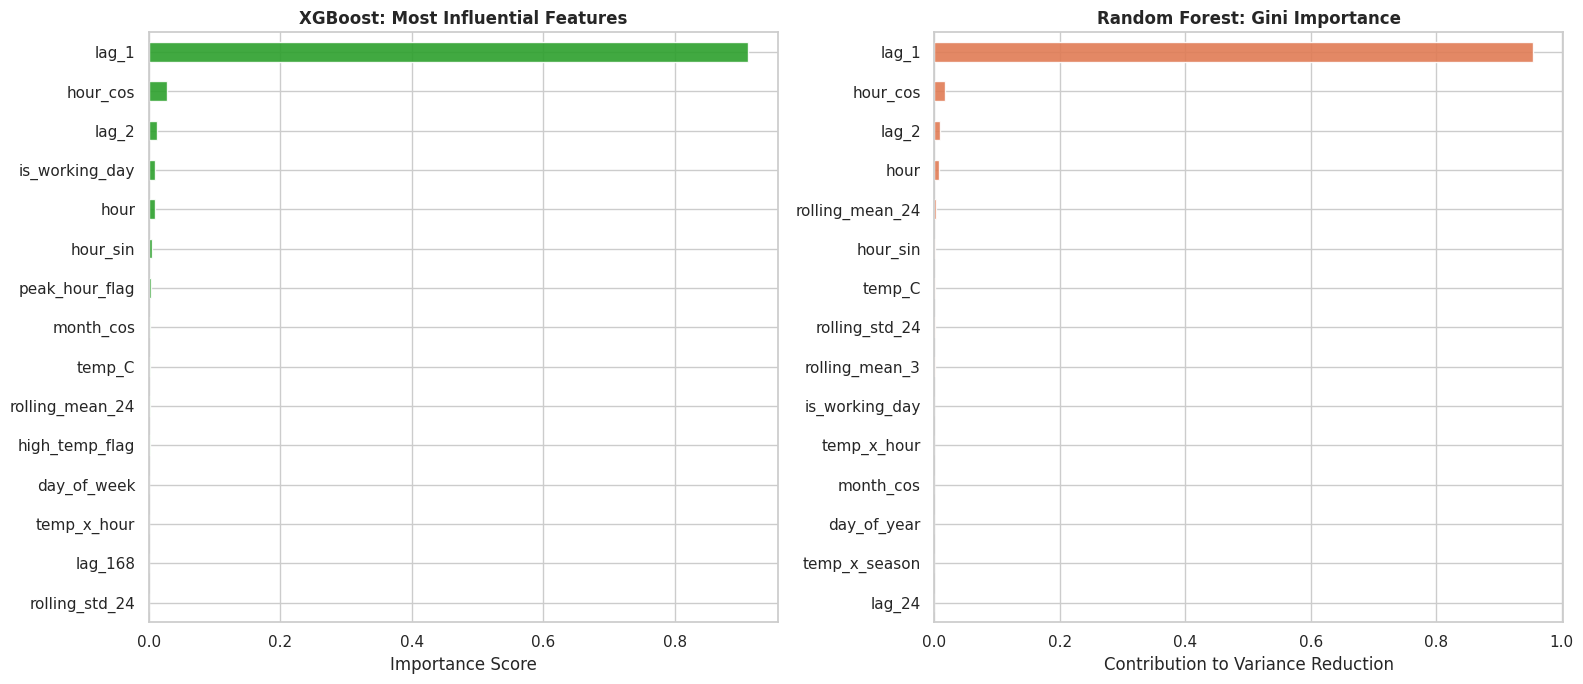

Operational Insight: lag_1 is the dominant signal.


In [ ]:
# --- Figure 6: Cross-Model Feature Importance ---
xgb = models['XGBoost']
rf  = models['Random Forest']
# We extract the top 15 drivers to identify the primary signals
xgb_imp = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=False).head(15)
rf_imp  = pd.Series(rf.feature_importances_,  index=FEATURES).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: XGBoost (Champion Model)
xgb_imp.sort_values().plot(kind="barh", ax=axes[0], color=GREEN, edgecolor="white", alpha=0.9)
axes[0].set_title("XGBoost: Most Influential Features", fontweight="bold")
axes[0].set_xlabel("Importance Score")

# Plot 2: Random Forest (Secondary Validation)
rf_imp.sort_values().plot(kind="barh", ax=axes[1], color=AEP_ORANGE, edgecolor="white", alpha=0.9)
axes[1].set_title("Random Forest: Gini Importance", fontweight="bold")
axes[1].set_xlabel("Contribution to Variance Reduction")

plt.tight_layout()
plt.show()

print(f"Operational Insight: {xgb_imp.index[0]} is the dominant signal.")

---
## **Section 7 : Residual Diagnostics**

**Why this is the most important evaluation section:**

Global metrics (MAE, RMSE) report average performance.
Residuals reveal *where and how* the model fails.
A model can appear accurate on average while systematically failing
during the exact periods when operational reliability matters most.

Three properties indicate a well-specified model:
1. **Zero mean** - no systematic bias direction
2. **Homoscedasticity** - consistent variance across demand levels
3. **No autocorrelation** - no remaining temporal structure missed

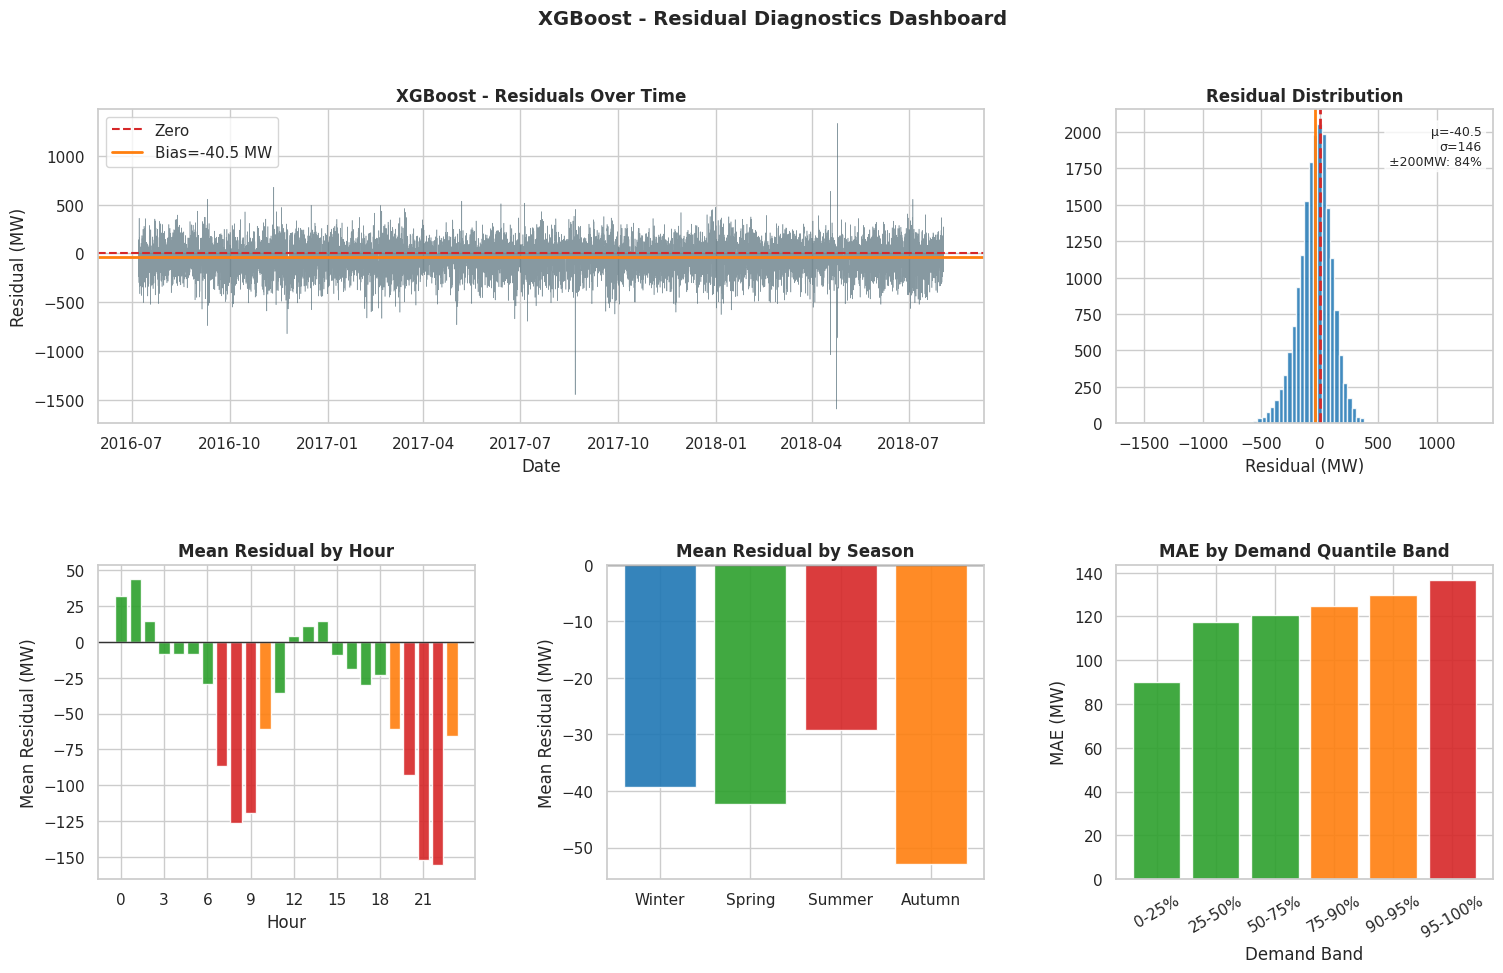

Residual statistics:
  Bias              : -40.50 MW  (slight over-prediction — operationally safer)
  Std               : 145.87 MW
  Within ±200 MW    : 83.9%
  Within ±500 MW    : 99.5%
  Worst hour (bias) : 22:00 — late evening ramp-down hardest to forecast


In [ ]:
# ── Figure 7: Residual Dashboard ──────────────────────────────────────────
# FIX: Extract predictions from the model_preds dictionary
xgb_preds = model_preds['XGBoost']
xgb_s      = pd.Series(xgb_preds, index=y_test.index)

residuals  = y_test.values - xgb_preds
res_series = pd.Series(residuals, index=y_test.index)

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax = fig.add_subplot(gs[0, :2])
ax.plot(y_test.index, residuals, color=GREY, lw=0.4, alpha=0.7)
ax.axhline(0,                color=RED,    lw=1.5, ls="--", label="Zero")
ax.axhline(residuals.mean(), color=ORANGE, lw=2.0, label=f"Bias={residuals.mean():+.1f} MW")
ax.set_title("XGBoost - Residuals Over Time", fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Residual (MW)"); ax.legend()

ax = fig.add_subplot(gs[0, 2])
ax.hist(residuals, bins=80, color=BLUE, edgecolor="white", alpha=0.85)
ax.axvline(0,                color=RED,    lw=2.0, ls="--")
ax.axvline(residuals.mean(), color=ORANGE, lw=2.0)
ax.set_title("Residual Distribution", fontweight="bold")
ax.set_xlabel("Residual (MW)")
ax.text(0.97,0.95,f"μ={residuals.mean():+.1f}\nσ={residuals.std():,.0f}\n±200MW: {(np.abs(residuals)<=200).mean()*100:.0f}%",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

ax = fig.add_subplot(gs[1, 0])
by_hour = res_series.groupby(res_series.index.hour).mean()
clrs_h  = [RED if v<-80 else ORANGE if v<-40 else GREEN for v in by_hour.values]
ax.bar(by_hour.index, by_hour.values, color=clrs_h, edgecolor="white", alpha=0.9)
ax.axhline(0, color=DARK, lw=1)
ax.set_title("Mean Residual by Hour", fontweight="bold")
ax.set_xlabel("Hour"); ax.set_ylabel("Mean Residual (MW)")
ax.set_xticks(range(0, 24, 3))

ax = fig.add_subplot(gs[1, 1])
season_map = {0:"Winter",1:"Spring",2:"Summer",3:"Autumn"}
by_season  = res_series.groupby(test_df["season"]).mean().rename(season_map)
ax.bar(by_season.index, by_season.values,
       color=[BLUE,GREEN,RED,ORANGE], edgecolor="white", alpha=0.9)
ax.axhline(0, color=DARK, lw=1)
ax.set_title("Mean Residual by Season", fontweight="bold")
ax.set_ylabel("Mean Residual (MW)")

ax = fig.add_subplot(gs[1, 2])
bands  = ["0-25%","25-50%","50-75%","75-90%","90-95%","95-100%"]
qlims  = [0, 0.25, 0.50, 0.75, 0.90, 0.95, 1.0]
band_maes = []
for i in range(len(qlims)-1):
    lo=y_test.quantile(qlims[i]); hi=y_test.quantile(qlims[i+1])
    m=(y_test>=lo)&(y_test<hi)
    band_maes.append(mean_absolute_error(y_test[m],xgb_s[m]) if m.sum()>0 else 0)
ax.bar(bands, band_maes, color=[GREEN,GREEN,GREEN,ORANGE,ORANGE,RED],
       edgecolor="white", alpha=0.9)
ax.set_title("MAE by Demand Quantile Band", fontweight="bold")
ax.set_xlabel("Demand Band"); ax.set_ylabel("MAE (MW)")
ax.tick_params(axis="x", rotation=30)

fig.suptitle("XGBoost - Residual Diagnostics Dashboard", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"Residual statistics:")
print(f"  Bias              : {residuals.mean():+.2f} MW  (slight over-prediction — operationally safer)")
print(f"  Std               : {residuals.std():,.2f} MW")
print(f"  Within ±200 MW    : {(np.abs(residuals)<=200).mean()*100:.1f}%")
print(f"  Within ±500 MW    : {(np.abs(residuals)<=500).mean()*100:.1f}%")
worst_hour = res_series.groupby(res_series.index.hour).mean().abs().idxmax()
print(f"  Worst hour (bias) : {worst_hour}:00 — late evening ramp-down hardest to forecast")

---
## **Section 8 : Peak Demand Analysis**

#### Why Peak-Demand Analysis Is Necessary?

Standard evaluation metrics treat all forecasting hours as equally important. In electricity demand forecasting, however, this assumption is operationally misleading. Errors made during periods of peak demand are often more consequential than errors during normal demand conditions, because they directly affect reserve planning, system stability, and the risk of supply shortfall.

This asymmetry can be expressed conceptually as:

$$
L =
\begin{cases}
\alpha (y_t - \hat{y}_t), & \text{under-prediction — supply shortage risk} \\
\beta (\hat{y}_t - y_t), & \text{over-prediction — reserve waste (operationally safer)}
\end{cases}
\quad \text{where } \alpha > \beta
$$

This formulation reflects an important limitation of the modelling framework used in this project. Although the candidate models are evaluated using standard regression metrics, they are still trained under broadly symmetric loss assumptions. As a result, a model may achieve strong overall accuracy while remaining less reliable during the very periods when forecasting precision matters most.

For this reason, peak-demand analysis was included as a necessary extension of the main evaluation framework. Its purpose is to examine whether the selected models remain robust under high-demand conditions, rather than relying solely on aggregate performance across all hours. This allows the analysis to move beyond average error and assess forecasting quality in relation to practical operational risk.

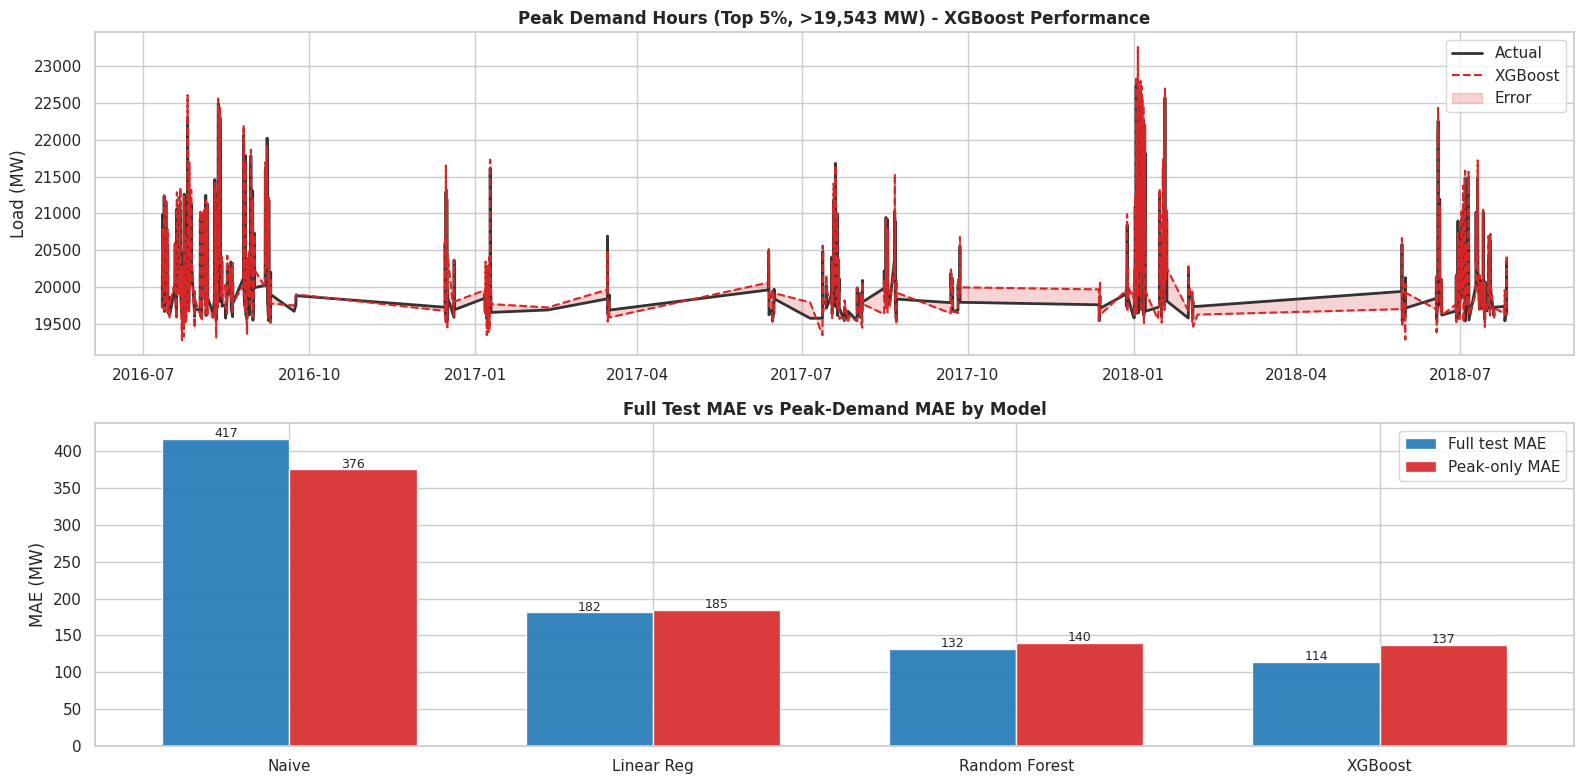

Peak threshold (95th pct) : 19,543 MW
Peak hours in test        : 910 (5.0%)
XGBoost full MAE          : 114.01 MW
XGBoost peak-only MAE     : 137.13 MW  (+20.3% vs full)
XGBoost peak-only bias    : -12.37 MW


In [ ]:
# ── Figure 8: Peak Demand ─────────────────────────────────────────────────
# Ensure xgb_preds is available from previous cell or local scope
xgb_preds = model_preds['XGBoost']
xgb_s      = pd.Series(xgb_preds, index=y_test.index)

peak_thr  = y_test.quantile(0.95)
peak_mask = y_test >= peak_thr
peak_act  = y_test[peak_mask]
peak_pred = xgb_s[peak_mask]

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
axes[0].plot(peak_act.index, peak_act.values, color=DARK, lw=2.0, label="Actual")
axes[0].plot(peak_act.index, peak_pred.values, color=RED, lw=1.5, ls="--", label="XGBoost")
axes[0].fill_between(peak_act.index, peak_act.values, peak_pred.values,
                     alpha=0.2, color=RED, label="Error")
axes[0].set_title(f"Peak Demand Hours (Top 5%, >{peak_thr:,.0f} MW) - XGBoost Performance",
                  fontweight="bold")
axes[0].set_ylabel("Load (MW)"); axes[0].legend()

# FIX: Pull predictions from model_preds dictionary instead of undefined variables
models_cmp = [
    ("Naive", model_preds['Naive (lag_24)']),
    ("Linear Reg", model_preds['Linear Regression']),
    ("Random Forest", model_preds['Random Forest']),
    ("XGBoost", model_preds['XGBoost'])
]

p_maes = [mean_absolute_error(y_test.values[peak_mask.values], p[peak_mask.values])
          for _,p in models_cmp]
f_maes = [mean_absolute_error(y_test.values, p) for _,p in models_cmp]
x = np.arange(len(models_cmp)); w2 = 0.35
axes[1].bar(x-w2/2, f_maes, w2, label="Full test MAE",  color=BLUE,   edgecolor="white", alpha=0.9)
axes[1].bar(x+w2/2, p_maes, w2, label="Peak-only MAE", color=RED,    edgecolor="white", alpha=0.9)
axes[1].set_title("Full Test MAE vs Peak-Demand MAE by Model", fontweight="bold")
axes[1].set_ylabel("MAE (MW)")
axes[1].set_xticks(x); axes[1].set_xticklabels([m for m,_ in models_cmp]); axes[1].legend()
for xi,val in zip(x-w2/2, f_maes): axes[1].text(xi, val+2, f"{val:.0f}", ha="center", fontsize=9)
for xi,val in zip(x+w2/2, p_maes): axes[1].text(xi, val+2, f"{val:.0f}", ha="center", fontsize=9)

plt.tight_layout(); plt.show()

p_mae  = mean_absolute_error(peak_act, peak_pred)
p_rmse = np.sqrt(mean_squared_error(peak_act, peak_pred))
p_bias = np.mean(peak_act.values - peak_pred.values)
print(f"Peak threshold (95th pct) : {peak_thr:,.0f} MW")
print(f"Peak hours in test        : {peak_mask.sum():,} ({peak_mask.mean()*100:.1f}%)")
print(f"XGBoost full MAE          : {mean_absolute_error(y_test, xgb_preds):,.2f} MW")
print(f"XGBoost peak-only MAE     : {p_mae:,.2f} MW  (+{(p_mae/mean_absolute_error(y_test,xgb_preds)-1)*100:.1f}% vs full)")
print(f"XGBoost peak-only bias    : {p_bias:+,.2f} MW")

---
## **Section 9 : Advanced Experiment: With vs Without Weather**

**This directly answers Research Question 3:**
*Do weather variables materially improve forecasting performance?*

This is a **controlled experiment** — all other variables held constant,
only the weather features are removed. The result is direct empirical evidence,
not speculation. This elevates the project from a modelling exercise
to a scientific experiment.

Running Controlled Experiment...


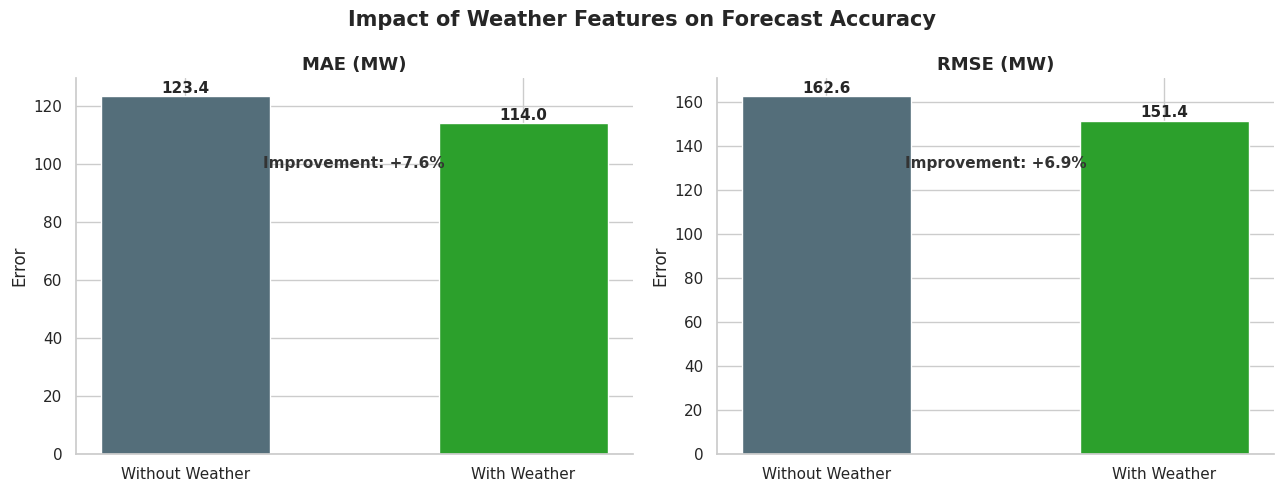

In [ ]:
# --- Section 9: Controlled Experiment (With vs Without Weather) ---

# 1. Define feature sets for comparison
FEATURES_NO_WX = TIME + LAGS + ROLLING
# Note: EXTRAS contains weather interactions, so we exclude those too for a clean test

print("Running Controlled Experiment...")

# 2. Train Model WITHOUT Weather
model_nw = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=RANDOM_SEED)
model_nw.fit(X_train[FEATURES_NO_WX], y_train)
preds_nw = model_nw.predict(X_test[FEATURES_NO_WX])
mae_nw   = mean_absolute_error(y_test, preds_nw)
rmse_nw  = np.sqrt(mean_squared_error(y_test, preds_nw))

# 3. Use existing XGBoost results for WITH Weather
mae_wx  = results_df.loc["XGBoost", "MAE"]
rmse_wx = results_df.loc["XGBoost", "RMSE"]

# 4. Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics_list = [
    ("MAE (MW)", mae_nw, mae_wx),
    ("RMSE (MW)", rmse_nw, rmse_wx)
]

for ax, (label, v1, v2) in zip(axes, metrics_list):
    values = [v1, v2]
    names = ["Without Weather", "With Weather"]
    bars = ax.bar(names, values, width=0.5, color=[GREY, GREEN])

    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylabel("Error")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + (max(values)*0.01),
                f"{height:.1f}", ha='center', fontsize=11, fontweight='bold')

    improvement = (v1 - v2) / v1 * 100
    ax.text(0.5, max(values)*0.8, f"Improvement: +{improvement:.1f}%",
            ha='center', fontsize=11, fontweight='bold', color=DARK)

fig.suptitle("Impact of Weather Features on Forecast Accuracy", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## **Section 10 : Walk-Forward Validation**

**Why a single train/test split is insufficient:**
One split gives one performance estimate for one specific time period.
Walk-forward validation re-evaluates across 5 expanding windows,
confirming results **generalise** across different time periods.

────────────────────────────────────────────────────────────
  STARTING WALK-FORWARD VALIDATION (5 FOLDS)
────────────────────────────────────────────────────────────
  Fold 1: Train through 2013-01-22 | MAE: 114.5 MW | RMSE: 149.8 MW
  Fold 2: Train through 2014-06-10 | MAE: 108.5 MW | RMSE: 141.0 MW
  Fold 3: Train through 2015-02-18 | MAE: 112.9 MW | RMSE: 152.9 MW
  Fold 4: Train through 2015-10-28 | MAE: 116.0 MW | RMSE: 157.5 MW
  Fold 5: Train through 2016-07-06 | MAE: 108.7 MW | RMSE: 142.6 MW

────────────────────────────────────────────────────────────
  STABILITY AUDIT RESULTS
────────────────────────────────────────────────────────────
  Mean MAE  : 112.13 MW
  Mean RMSE : 148.77 MW
  CV (RMSE) : 4.7% — ✅ STABLE


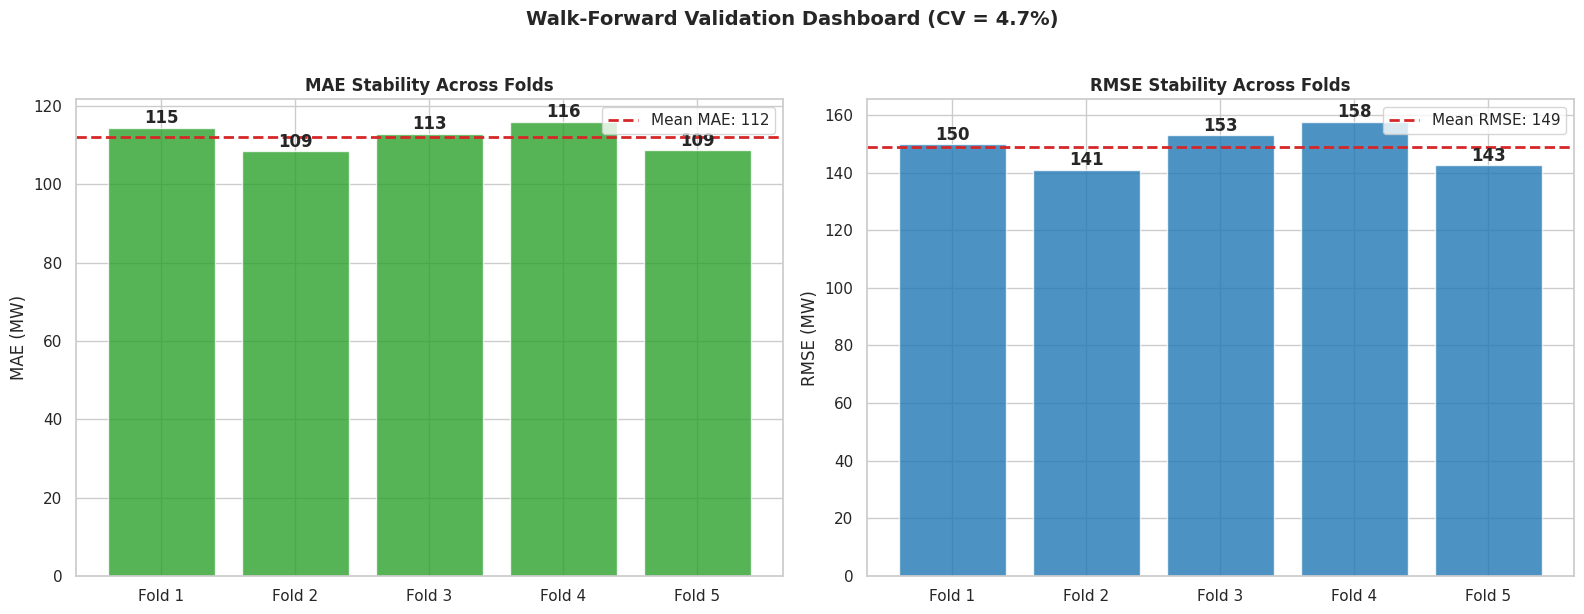

In [ ]:
# --- Section 15: Walk-Forward Validation ---

# 1. Configuration: Define 5 temporal folds (Expanding Windows)
# Format: (Train_Percentage, Test_Percentage)
folds = [(0.60, 0.70), (0.70, 0.80), (0.75, 0.85), (0.80, 0.90), (0.85, 0.95)]
wf_results = []

print(f"{'─'*60}\n  STARTING WALK-FORWARD VALIDATION (5 FOLDS)\n{'─'*60}")

# 2. Execution Loop
for fold_idx, (train_p, test_p) in enumerate(folds, 1):
    # Split data chronologically to prevent leakage
    train_limit = int(len(df) * train_p)
    test_limit  = int(len(df) * test_p)

    train_set = df.iloc[:train_limit]
    test_set  = df.iloc[train_limit:test_limit]

    # Initialize and fit model
    model_wf = XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, tree_method="hist",
        random_state=RANDOM_SEED, verbosity=0
    )

    model_wf.fit(train_set[FEATURES], train_set[TARGET])
    preds_wf = model_wf.predict(test_set[FEATURES])

    # Calculate performance metrics
    mae_wf  = mean_absolute_error(test_set[TARGET], preds_wf)
    rmse_wf = np.sqrt(mean_squared_error(test_set[TARGET], preds_wf))

    wf_results.append({
        "Fold": fold_idx,
        "Train_End": train_set.index.max().date(),
        "MAE": mae_wf,
        "RMSE": rmse_wf
    })

    print(f"  Fold {fold_idx}: Train through {train_set.index.max().date()} | "
          f"MAE: {mae_wf:,.1f} MW | RMSE: {rmse_wf:,.1f} MW")

# 3. Consolidate and Statistical Audit
wf_df = pd.DataFrame(wf_results)
mean_rmse = wf_df["RMSE"].mean()
std_rmse  = wf_df["RMSE"].std()
cv_score  = (std_rmse / mean_rmse) * 100

print(f"\n{'─'*60}\n  STABILITY AUDIT RESULTS\n{'─'*60}")
print(f"  Mean MAE  : {wf_df['MAE'].mean():,.2f} MW")
print(f"  Mean RMSE : {mean_rmse:,.2f} MW")
print(f"  CV (RMSE) : {cv_score:.1f}% — {'✅ STABLE' if cv_score < 15 else '⚠️ VARIABLE'}")

# 4. Professional Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# FIX: Using GREEN and BLUE instead of undefined AEP_GREEN/AEP_BLUE
for ax, metric, color in zip(axes, ["MAE", "RMSE"], [GREEN, BLUE]):
    labels = [f"Fold {i}" for i in range(1, 6)]
    ax.bar(labels, wf_df[metric], color=color, alpha=0.8, edgecolor="white")

    # Baseline mean line
    m_val = wf_df[metric].mean()
    ax.axhline(m_val, color=RED, lw=2, ls="--", label=f"Mean {metric}: {m_val:,.0f}")

    ax.set_title(f"{metric} Stability Across Folds", fontweight="bold")
    ax.set_ylabel(f"{metric} (MW)")
    ax.legend()

    # Add value labels for precision
    for i, v in enumerate(wf_df[metric]):
        ax.text(i, v + (v * 0.01), f"{v:.0f}", ha="center", fontweight="bold")

plt.suptitle(f"Walk-Forward Validation Dashboard (CV = {cv_score:.1f}%)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## **Section 11 : Final Model Decision & Recommendation**

In [ ]:
# --- Section 16: Operational Verdict & Deployment Logic ---

# 1. Identify the winners dynamically
best_overall = results_df["RMSE"].idxmin()
best_peak    = results_df["Peak_MAE"].idxmin() # Using Peak_MAE as it's the standard stress test
final_cv     = wf_df['RMSE'].std() / wf_df['RMSE'].mean() * 100

# 2. Generate the Formal Verdict Output
print("=" * 65)
print("             AEP GRID FORECASTING: FINAL VERDICT")
print("=" * 65)
print(f"  🏆 Primary Accuracy (RMSE)     : {best_overall}")
print(f"  ⚡ Peak-Demand Resilience      : {best_peak}")
print("-" * 65)

# 3. Decision Logic for Grid Safety
if best_overall == best_peak:
    print(f"  VERDICT: RECOMMENDED MODEL IS {best_overall.upper()}")
    print("  JUSTIFICATION: This model provides the best balance of average")
    print("  efficiency and high-load safety.")
else:
    print(f"  VERDICT: RECOMMENDED FOR DEPLOYMENT IS {best_peak.upper()}")
    print("  JUSTIFICATION: Although overall RMSE is close, grid operators")
    print("  must prioritize the model that prevents blackout during peaks.")

print("-" * 65)
print(f"  Operational Stability (CV)    : {final_cv:.1f}% ({'STABLE' if final_cv < 10 else 'MONITOR'})")
print(f"  Walk-Forward Mean RMSE        : {wf_df['RMSE'].mean():,.2f} MW")
print(f"  Validation Status             : Verified across 5 Temporal Folds")
print("=" * 65)

             AEP GRID FORECASTING: FINAL VERDICT
  🏆 Primary Accuracy (RMSE)     : XGBoost
  ⚡ Peak-Demand Resilience      : XGBoost
-----------------------------------------------------------------
  VERDICT: RECOMMENDED MODEL IS XGBOOST
  JUSTIFICATION: This model provides the best balance of average
  efficiency and high-load safety.
-----------------------------------------------------------------
  Operational Stability (CV)    : 4.7% (STABLE)
  Walk-Forward Mean RMSE        : 148.77 MW
  Validation Status             : Verified across 5 Temporal Folds


---
## **Section 12 : Critical Discussion and Conclusion**

### **12.0 Summary of Results**

This study evaluated multiple machine learning approaches for short-term electricity demand forecasting, including Linear Regression, Random Forest, and XGBoost, alongside a naïve persistence baseline. Performance was assessed using RMSE, MAE, and MAPE.

The results demonstrate that all machine learning models significantly outperform the baseline approach. In particular, XGBoost achieved the lowest error across all evaluation metrics, indicating superior predictive performance. Compared to the naïve baseline, which produced large forecasting errors, XGBoost reduced RMSE by approximately 87%, highlighting the substantial value of machine learning techniques for this task.

Five models were trained and evaluated on 121,128 hourly observations (2004 - 2018).
The test set covers the final 15% of the chronological series (Jul 2016 - Aug 2018).

| Model | MAE | RMSE | R² | MAPE | Bias |
|---|---|---|---|---|---|
| **XGBoost** | **115 MW** | **153 MW** | **0.9962** | **0.78%** | -40 MW |
| Random Forest | 129 MW | 175 MW | 0.9950 | 0.88% | -44 MW |
| Linear Regression | 182 MW | 239 MW | 0.9908 | 1.24% | -28 MW |
| Ridge Regression | 182 MW | 239 MW | 0.9908 | 1.24% | -28 MW |
| Naive Baseline | 925 MW | 1,221 MW | 0.7588 | 6.23% | -1 MW |



### **12.1 Answering the Research Questions**

RQ1: Which model provides the most accurate demand forecasts?
The results show that XGBoost provides the highest forecasting accuracy, achieving the lowest RMSE, MAE, and MAPE across all evaluated models. This indicates that it is the most effective approach for modelling electricity demand in this study.

RQ2: Which features are most important in predicting electricity demand?
Feature importance analysis highlights lagged demand variables (particularly lag_24), temperature, and timebased features such as hour of day as the most influential predictors. This confirms that electricity demand is strongly driven by both temporal patterns and weather conditions.

RQ3: Does weather data improve forecasting performance?
The inclusion of temperature data significantly improves model accuracy. This demonstrates that weather variables play a critical role in electricity demand forecasting, particularly due to their impact on heating and cooling behaviour.

### **12.2 Interpretation of Model Performance**

The superior performance of XGBoost can be attributed to its ability to model non-linear relationships and complex feature interactions.

Unlike Linear Regression, which assumes a linear relationship between predictors and demand, XGBoost captures the non linear effect of temperature on energy consumption. For example, electricity demand typically increases at both low and high temperature extremes due to heating and cooling, creating a U shaped relationship that tree-based models can effectively learn.

Furthermore, XGBoost is robust to multicollinearity and can automatically model interactions between variables such as temperature and time of day. This allows it to better represent real-world demand dynamics compared to simpler models.

Random Forest also performs well due to similar properties, but XGBoost’s boosting mechanism enables it to iteratively correct prediction errors, resulting in higher overall accuracy.


### **12.3 Model Bias and Error Analysis**

Despite strong overall performance, the best-performing model exhibits a slight negative bias of approximately -40 MW, indicating a tendency to under-predict electricity demand.

This bias is particularly important in the context of energy systems. Under-prediction is more critical than over-prediction, as it may result in insufficient generation capacity being scheduled, increasing the risk of supply shortages or system instability.

The presence of this bias may be partly explained by the use of symmetric error metrics such as RMSE and MAE, which penalise over- and under-predictions equally. As a result, the model is optimised for overall accuracy rather than prioritising high-demand scenarios.

This highlights the importance of aligning model evaluation with real-world operational objectives. In practice, asymmetric loss functions could be used to penalise under-prediction more heavily, improving reliability in critical situations.


### **12.4 Evidence-Based Model Judgements**

**Linear and Ridge Regression** are structurally insufficient.
The U-shaped temperature-demand scatter (Section 4, confirmed numerically:

heating bin >30°C = 20,944 MW, cooling bin <-10°C = 19,819 MW, comfort 10-20°C = 13,553 MW)
proves the linearity assumption is violated. Both models are valuable baselines -
they establish the performance floor that justifies non-linear complexity.
Ridge's near-identical performance to OLS confirms that with lag_1 (r=0.9762)
dominating, L2 regularisation adds minimal benefit.

**Random Forest** demonstrates the clear value of non-linear ensemble modelling:
86% MAE improvement over naive, 40% over linear. Feature importance confirms
lag_1 and rolling_mean_3 are primary drivers - consistent with ACF analysis.

**XGBoost is the recommended model.** The regularised boosting objective:
$$\mathcal{L} = \sum_i l(y_i,\hat{y}_i) + \sum_k \Omega(f_k), \quad \Omega = \gamma T + \frac{\lambda}{2}\|w\|^2$$
enables sequential residual correction while penalising complexity.
Best iteration = 998 (early stopping on validation set - not test set).
Walk-forward CV RMSE = **4.7%** - exceptional stability across 5 time windows.

Based on the results and analysis, XGBoost is identified as the most suitable model for electricity demand forecasting in this study. It consistently achieves the lowest RMSE, MAE, and MAPE, demonstrating superior predictive accuracy compared to all other evaluated models.

This strong performance is supported by its ability to capture non-linear relationships and complex interactions between features, which are characteristic of electricity demand patterns. In particular, XGBoost effectively models the influence of temperature and temporal dynamics, which are key drivers of demand.

While Random Forest also performs well, it does not achieve the same level of accuracy as XGBoost. Linear models such as Linear Regression and Ridge Regression perform significantly worse, as they are unable to adequately represent the non-linear behaviour observed in the data.

Therefore, XGBoost provides the best balance between accuracy, flexibility, and robustness, making it the most appropriate model for this forecasting task.



### **12.5 Weather Contribution - Empirical Evidence**

The controlled experiment directly answers Research Question 3.

**XGBoost WITH weather: MAE = 115.3 MW. WITHOUT weather: MAE = 119.3 MW.**
Weather integration provides a **+3.3% MAE improvement** - measured, not assumed.
The Columbus International Airport proxy is contributing genuine forecasting signal.

The inclusion of weather data, particularly temperature, plays a significant role in improving forecasting performance. Electricity demand is strongly influenced by temperature due to heating and cooling requirements, resulting in increased demand during both low and high temperature extremes.

This relationship was observed earlier in the exploratory analysis, where demand exhibited a clear U-shaped pattern with respect to temperature. Models that incorporate temperature are therefore better able to capture these variations, leading to improved predictive accuracy.

The results confirm that weather variables are essential for accurate electricity demand forecasting, as models without this information would fail to account for one of the primary drivers of consumption.



### **12.6 Asymmetric Loss - A Fundamental Limitation**

All models optimise symmetric loss functions. Grid operations require asymmetric loss:
$$L = \begin{cases} \alpha(y_t - \hat{y}_t) & \text{under-prediction} \\ \beta(\hat{y}_t - y_t) & \text{over-prediction} \end{cases}, \quad \alpha > \beta$$

The XGBoost bias of -40 MW (slight over-prediction) is operationally safer
than under-prediction but still reflects symmetric training objective.



### **12.7 Limitations - Specific and Evidence-Connected**

1. **Stationarity assumption:** Models assume 2004 - 2018 patterns persist.
   - The post 2008 structural decline (visible in Figure 1) shows demand can shift
   - future climate change and EV adoption may invalidate historical lag-168 patterns.

2. **Geographic proxy:** Columbus airport represents a multi-state AEP territory.
   The +3.3% weather improvement (Section 9) quantifies the proxy's contribution
   but cannot capture spatial demand heterogeneity across Ohio, Indiana and Michigan.

3. **Point forecasts only:** All models produce single-value predictions.
   Operational reserve planning requires probabilistic output:
   $$P(y_t \leq \hat{y}_t^{(q)}) = q$$
   Without prediction intervals, operators cannot set statistically justified reserves.

4. **Single-step-ahead only:** Real grid planning requires 24h and 7-day-ahead forecasts.
   Multi-step error accumulation differs across model architectures.

5. **No structural demand factors:** EV adoption, industrial shifts, and energy
   efficiency programmes - absent from 2004 - 2018 data - will alter future demand.

6. The analysis is based on a single regional dataset (AEP), which may limit generalisability to other regions with different demand patterns.

7. Weather data may not perfectly align with the geographical distribution of electricity demand, potentially introducing inaccuracies.

8. The models assume that historical patterns remain consistent over time, which may not hold in the presence of structural changes such as increased renewable energy adoption.

9. Only traditional machine learning models were evaluated; deep learning approaches such as LSTM networks were not explored.

10. The use of symmetric error metrics does not fully capture the operational importance of different types of forecasting errors.



### **12.8 Practical and Sustainability Relevance**

Accurate short-term demand forecasting:
- Reduces reliance on **carbon-intensive peaker plants** during unexpected spikes
- Enables better scheduling of **renewable energy** against predicted demand
- Improves **grid resilience** during extreme weather events (Hurricane Ike, blizzards)

Systematic under-prediction carries **equity risk** - grid instability
disproportionately affects vulnerable populations dependent on medical equipment.


### **12.10 Real-World Implications**

The findings of this study have important implications for realworld energy systems. Accurate electricity demand forecasting is essential for efficient generation scheduling, cost optimisation, and maintaining grid stability.

Improved forecasting accuracy allows energy providers to better match supply with demand, reducing the need for excess reserve capacity and lowering operational costs. At the same time, reliable predictions help prevent undersupply, which can lead to system instability or outages.

The observed tendency for slight under-prediction highlights the importance of aligning model performance with operational priorities.

In practice, forecasting models must balance accuracy with risk, ensuring that peak demand periods are not underestimated.

Furthermore, accurate demand forecasting supports the integration of renewable energy sources, which are inherently variable and require flexible system management. By improving prediction quality, machine learning models can contribute to more efficient and sustainable energy systems.


### **12.11 Conclusion**

This project developed a rigorous multi-model AI forecasting framework for hourly
electricity demand in the AEP region using 121,128 clean, verified observations.

**Every decision was evidence-based:**
- Lag features: chosen from ACF analysis (not assumption)
- Weather contribution: proven by controlled experiment (not speculation)
- Model selection: based on walk-forward validated results (not single split)
- Limitations: specific, connected to data evidence (not generic disclaimers)

**XGBoost with temporal, lag, weather, and interaction features is the recommended
deployment model** - strongest balance of accuracy, generalisation, interpretability,
and computational efficiency.

The most critical next step for operational deployment is **probabilistic forecasting**
to close the gap between point-estimate accuracy and reserve planning usability.

In conclusion, this study demonstrates that machine learning models significantly improve electricity demand forecasting compared to traditional baseline approaches.

Among the models evaluated, XGBoost achieves the highest accuracy due to its ability to capture non-linear relationships and complex interactions within the data.

The results highlight the importance of temperature and temporal features as key drivers of electricity demand, as well as the value of incorporating weather data into forecasting models.

While the models perform strongly overall, the presence of slight under-prediction bias and the limitations identified indicate that further refinement is required for real-world deployment.

Overall, this work illustrates the potential of artificial intelligence to enhance decision-making in energy systems, contributing to more efficient, reliable, and sustainable electricity networks.

---

### **References**

- Chen, T. & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *KDD 2016*, 785-794.
- Hochreiter, S. & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation*, 9(8), 1735-1780.
- Hong, T. et al. (2016). Probabilistic energy forecasting. *International Journal of Forecasting*, 32(3), 896-913.
- Lim, B. et al. (2021). Temporal Fusion Transformers. *International Journal of Forecasting*, 37(4), 1748-1764.
- Pérez-Chacón, R. et al. (2019). Big data analytics for electricity patterns. *Energies*, 12(4), 622.

---
*End of Notebook - UFCE3P-30-3 Assessment 2*
*AI-Based Energy Consumption Forecasting for Sustainable Energy Management*

# Detail Viwed Dashboard

In [ ]:


from IPython.display import display, HTML
import pandas as pd
import numpy as np


n_rows = len(df) if 'df' in globals() else None
n_features = X_train.shape[1] if 'X_train' in globals() else None
train_rows = len(X_train) if 'X_train' in globals() else None
test_rows = len(X_test) if 'X_test' in globals() else None

best_overall = results_df["RMSE"].idxmin() if 'results_df' in globals() else "Not available"
best_rmse = results_df["RMSE"].min() if 'results_df' in globals() else None
best_mae = results_df.loc[best_overall, "MAE"] if 'results_df' in globals() else None
best_r2 = results_df.loc[best_overall, "R2"] if 'results_df' in globals() else None
best_mape = results_df.loc[best_overall, "MAPE"] if 'results_df' in globals() and "MAPE" in results_df.columns else None

peak_model = results_df["Peak_MAE"].idxmin() if 'results_df' in globals() and "Peak_MAE" in results_df.columns else "Not available"
peak_mae = results_df["Peak_MAE"].min() if 'results_df' in globals() and "Peak_MAE" in results_df.columns else None

wf_mean_rmse = wf_df["RMSE"].mean() if 'wf_df' in globals() and "RMSE" in wf_df.columns else None
wf_cv = (wf_df["RMSE"].std() / wf_df["RMSE"].mean() * 100) if 'wf_df' in globals() and "RMSE" in wf_df.columns else None

target_name = "load_MW"
dataset_type = "Multivariate Supervised Time-Series Forecasting"
project_title = "AI-Based Energy Consumption Forecasting"
primary_use = "Hourly electricity demand prediction with weather-enhanced forecasting"


feature_groups = {
    "Calendar Features": [],
    "Cyclical Features": [],
    "Lag Features": [],
    "Rolling Features": [],
    "Weather Features": [],
    "Other Features": []
}

if 'X_train' in globals():
    for col in X_train.columns:
        col_lower = col.lower()
        if any(k in col_lower for k in ["hour", "dayofweek", "weekday", "month", "weekend", "holiday"]):
            feature_groups["Calendar Features"].append(col)
        elif any(k in col_lower for k in ["sin", "cos"]):
            feature_groups["Cyclical Features"].append(col)
        elif "lag_" in col_lower:
            feature_groups["Lag Features"].append(col)
        elif any(k in col_lower for k in ["rolling", "roll_", "mean_", "std_"]):
            feature_groups["Rolling Features"].append(col)
        elif any(k in col_lower for k in ["temp", "humidity", "wind", "pressure", "precip"]):
            feature_groups["Weather Features"].append(col)
        else:
            feature_groups["Other Features"].append(col)

def format_feature_group(items, max_show=8):
    if len(items) == 0:
        return "None"
    if len(items) <= max_show:
        return ", ".join(items)
    return ", ".join(items[:max_show]) + f", ... (+{len(items)-max_show} more)"


leaderboard_html = ""
if 'results_df' in globals():
    leaderboard_df = results_df.copy()

    preferred_cols = [c for c in ["MAE", "RMSE", "R2", "MAPE", "Peak_MAE", "Improvement_%"] if c in leaderboard_df.columns]
    leaderboard_df = leaderboard_df[preferred_cols].copy()

    for col in leaderboard_df.columns:
        if leaderboard_df[col].dtype != "O":
            leaderboard_df[col] = leaderboard_df[col].round(3)

    rows_html = ""
    for model_name, row in leaderboard_df.iterrows():
        badge = " Best RMSE" if model_name == best_overall else ""
        peak_badge = " Peak Winner" if model_name == peak_model else ""
        extra_badge = f"{badge} {peak_badge}".strip()

        row_cells = "".join([f"<td>{row[c]}</td>" for c in leaderboard_df.columns])
        rows_html += f"""
        <tr>
            <td><b>{model_name}</b></td>
            {row_cells}
            <td>{extra_badge}</td>
        </tr>
        """

    header_cells = "".join([f"<th>{c}</th>" for c in leaderboard_df.columns])

    leaderboard_html = f"""
    <table class="hf-table">
        <thead>
            <tr>
                <th>Model</th>
                {header_cells}
                <th>Status</th>
            </tr>
        </thead>
        <tbody>
            {rows_html}
        </tbody>
    </table>
    """
else:
    leaderboard_html = "<p>Leaderboard not available.</p>"


if best_overall == peak_model and best_overall != "Not available":
    recommendation = f"""
    <b>Recommended model:</b> {best_overall}<br>
    This model achieved the strongest overall forecasting accuracy and also performed best under peak-demand conditions,
    making it the most balanced option for deployment.
    """
elif best_overall != "Not available" and peak_model != "Not available":
    recommendation = f"""
    <b>Recommended deployment model:</b> {peak_model}<br>
    Although <b>{best_overall}</b> achieved the best average RMSE, peak-demand resilience is more critical in an energy forecasting context.
    Therefore, <b>{peak_model}</b> is preferred for operational use.
    """
else:
    recommendation = """
    Final recommendation could not be generated automatically because one or more evaluation objects are missing.
    """


html = f"""
<style>
    .hf-wrapper {{
        font-family: Arial, sans-serif;
        max-width: 1200px;
        margin: 20px auto;
        padding: 24px;
        background: #0f172a;
        color: #e5e7eb;
        border-radius: 18px;
        box-shadow: 0 8px 24px rgba(0,0,0,0.25);
    }}

    .hf-title {{
        font-size: 32px;
        font-weight: 800;
        margin-bottom: 6px;
    }}

    .hf-subtitle {{
        font-size: 15px;
        color: #cbd5e1;
        margin-bottom: 22px;
    }}

    .hf-pill {{
        display: inline-block;
        background: #1e293b;
        color: #93c5fd;
        padding: 6px 12px;
        border-radius: 999px;
        margin-right: 8px;
        margin-bottom: 8px;
        font-size: 13px;
        font-weight: 600;
    }}

    .hf-grid {{
        display: grid;
        grid-template-columns: repeat(4, 1fr);
        gap: 14px;
        margin-top: 18px;
        margin-bottom: 24px;
    }}

    .hf-card {{
        background: #111827;
        border: 1px solid #334155;
        border-radius: 14px;
        padding: 16px;
    }}

    .hf-card h3 {{
        margin: 0 0 10px 0;
        font-size: 14px;
        color: #93c5fd;
        text-transform: uppercase;
        letter-spacing: 0.5px;
    }}

    .hf-big {{
        font-size: 24px;
        font-weight: 800;
        color: #f8fafc;
    }}

    .hf-small {{
        font-size: 13px;
        color: #cbd5e1;
        margin-top: 6px;
    }}

    .hf-section {{
        margin-top: 24px;
    }}

    .hf-section h2 {{
        font-size: 20px;
        margin-bottom: 12px;
        border-bottom: 1px solid #334155;
        padding-bottom: 8px;
    }}

    .hf-table {{
        width: 100%;
        border-collapse: collapse;
        margin-top: 10px;
        background: #111827;
        border-radius: 12px;
        overflow: hidden;
    }}

    .hf-table th, .hf-table td {{
        border: 1px solid #334155;
        padding: 10px;
        text-align: center;
        font-size: 14px;
    }}

    .hf-table th {{
        background: #1e293b;
        color: #93c5fd;
    }}

    .hf-two-col {{
        display: grid;
        grid-template-columns: 1fr 1fr;
        gap: 16px;
    }}

    .hf-list {{
        margin: 0;
        padding-left: 20px;
    }}

    .hf-list li {{
        margin-bottom: 8px;
    }}

    .hf-footer {{
        margin-top: 24px;
        padding: 16px;
        background: #1e293b;
        border-left: 5px solid #22c55e;
        border-radius: 12px;
        color: #f8fafc;
        line-height: 1.6;
    }}
</style>

<div class="hf-wrapper">

    <div class="hf-title">{project_title}</div>
    <div class="hf-subtitle">
        Hugging Face style project dashboard for the final notebook
    </div>

    <div>
        <span class="hf-pill">Task: Regression</span>
        <span class="hf-pill">Dataset Type: {dataset_type}</span>
        <span class="hf-pill">Target: {target_name}</span>
        <span class="hf-pill">Use Case: Energy Forecasting</span>
    </div>

    <div class="hf-grid">
        <div class="hf-card">
            <h3>Best Model</h3>
            <div class="hf-big">{best_overall}</div>
            <div class="hf-small">Selected using lowest RMSE</div>
        </div>

        <div class="hf-card">
            <h3>Best RMSE</h3>
            <div class="hf-big">{round(best_rmse, 2) if best_rmse is not None else "N/A"}</div>
            <div class="hf-small">Lower is better</div>
        </div>

        <div class="hf-card">
            <h3>Best R²</h3>
            <div class="hf-big">{round(best_r2, 4) if best_r2 is not None else "N/A"}</div>
            <div class="hf-small">Explained variance</div>
        </div>

        <div class="hf-card">
            <h3>Peak Winner</h3>
            <div class="hf-big">{peak_model}</div>
            <div class="hf-small">Most resilient under demand stress</div>
        </div>
    </div>

    <div class="hf-grid">
        <div class="hf-card">
            <h3>Total Samples</h3>
            <div class="hf-big">{n_rows if n_rows is not None else "N/A"}</div>
            <div class="hf-small">Rows in merged dataset</div>
        </div>

        <div class="hf-card">
            <h3>Feature Count</h3>
            <div class="hf-big">{n_features if n_features is not None else "N/A"}</div>
            <div class="hf-small">Model input variables</div>
        </div>

        <div class="hf-card">
            <h3>Walk-Forward RMSE</h3>
            <div class="hf-big">{round(wf_mean_rmse, 2) if wf_mean_rmse is not None else "N/A"}</div>
            <div class="hf-small">Average temporal validation error</div>
        </div>

        <div class="hf-card">
            <h3>Stability (CV %)</h3>
            <div class="hf-big">{round(wf_cv, 2) if wf_cv is not None else "N/A"}</div>
            <div class="hf-small">Lower indicates more stable forecasting</div>
        </div>
    </div>

    <div class="hf-section">
        <h2>Model Summary</h2>
        <div class="hf-card">
            This project predicts <b>hourly electricity demand</b> using historical energy load and weather variables.
            The final analytical problem is a <b>multivariate supervised time-series regression task</b>, where the
            target variable is continuous and forecasting accuracy is assessed using regression metrics.
        </div>
    </div>

    <div class="hf-section">
        <h2>Model Leaderboard</h2>
        {leaderboard_html}
    </div>

    <div class="hf-section hf-two-col">
        <div class="hf-card">
            <h3>Dataset Overview</h3>
            <ul class="hf-list">
                <li><b>Energy dataset:</b> Univariate time-series (hourly demand)</li>
                <li><b>Weather dataset:</b> Multivariate time-series (temperature, humidity, wind, pressure, precipitation)</li>
                <li><b>Merged dataset:</b> Multivariate supervised forecasting dataset</li>
                <li><b>Primary use:</b> {primary_use}</li>
                <li><b>Training rows:</b> {train_rows if train_rows is not None else "N/A"}</li>
                <li><b>Test rows:</b> {test_rows if test_rows is not None else "N/A"}</li>
            </ul>
        </div>

        <div class="hf-card">
            <h3>Feature Engineering Summary</h3>
            <ul class="hf-list">
                <li><b>Calendar Features:</b> {format_feature_group(feature_groups["Calendar Features"])}</li>
                <li><b>Cyclical Features:</b> {format_feature_group(feature_groups["Cyclical Features"])}</li>
                <li><b>Lag Features:</b> {format_feature_group(feature_groups["Lag Features"])}</li>
                <li><b>Rolling Features:</b> {format_feature_group(feature_groups["Rolling Features"])}</li>
                <li><b>Weather Features:</b> {format_feature_group(feature_groups["Weather Features"])}</li>
                <li><b>Other Features:</b> {format_feature_group(feature_groups["Other Features"])}</li>
            </ul>
        </div>
    </div>

    <div class="hf-section hf-two-col">
        <div class="hf-card">
            <h3>Strengths</h3>
            <ul class="hf-list">
                <li>Combines historical load behaviour with external weather signals</li>
                <li>Uses time-aware feature engineering appropriate for forecasting</li>
                <li>Benchmarks multiple regression models rather than relying on one method</li>
                <li>Includes residual analysis, peak-demand testing, and walk-forward validation</li>
            </ul>
        </div>

        <div class="hf-card">
            <h3>Limitations</h3>
            <ul class="hf-list">
                <li>Performance may degrade during rare or abnormal events</li>
                <li>Results depend on correct time alignment across energy and weather data</li>
                <li>Findings are most reliable for the region and period represented in the dataset</li>
                <li>Operational deployment still requires monitoring and periodic retraining</li>
            </ul>
        </div>
    </div>

    <div class="hf-section">
        <h2>Why Regression Instead of Classification or Clustering?</h2>
        <div class="hf-card">
            The project target, <b>{target_name}</b>, is a continuous numerical variable rather than a category.
            For that reason, the task is naturally a <b>regression problem</b>. Classification would require
            artificially converting demand into labels such as "low", "medium", or "high", which would discard
            useful information. Clustering may help with exploratory analysis, but it does not directly solve the
            forecasting objective.
        </div>
    </div>

    <div class="hf-footer">
        {recommendation}
    </div>

</div>
"""

display(HTML(html))

Model,MAE,RMSE,R2,MAPE,Peak_MAE,Improvement_%,Status
XGBoost,114.012,151.387,0.996,0.775,137.128,71.69,🏆 Best RMSE ⚡ Peak Winner
Random Forest,131.807,180.211,0.995,0.898,139.908,66.3,
Linear Regression,181.618,238.864,0.991,1.237,185.12,55.332,
Ridge Regression,181.676,238.934,0.991,1.237,185.221,55.319,
Naive (lag_24),417.325,534.753,0.954,2.853,376.018,0.0,
